`python 3.12.10` was used.

In [ ]:
# !pip install gensim==3.7.0
# !pip install pingouin
# !pip install umap-learn
# !pip install xgboost

In the file `gensim\matutils.py`, replace `from scipy.linalg.special_matrices import triu` with `from numpy import triu`.

In the file `gensim\corpora\dictionary.py`, replace `from collections import Mapping, defaultdict` with `from collections.abc import Mapping; from collections import defaultdict`.

In [2]:
from gensim.models import KeyedVectors
from collections import Counter
import pandas as pd
import numpy as np
from scipy.spatial.distance import cosine, pdist, cdist
from scipy.stats import t as t_statistics, spearmanr
import pingouin as pg
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import cross_val_predict, KFold
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.preprocessing import LabelEncoder
import umap
import xgboost as xgb

d:\coding\thesis\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
def transliterate(text):
    iso9_map = {
        'а': 'a', 'б': 'b', 'в': 'v', 'г': 'g', 'д': 'd',
        'е': 'e', 'ё': 'ë', 'ж': 'ž', 'з': 'z', 'и': 'i',
        'й': 'j', 'к': 'k', 'л': 'l', 'м': 'm', 'н': 'n',
        'о': 'o', 'п': 'p', 'р': 'r', 'с': 's', 'т': 't',
        'у': 'u', 'ф': 'f', 'х': 'h', 'ц': 'c', 'ч': 'č',
        'ш': 'š', 'щ': 'ŝ', 'ъ': '"', 'ы': 'y', 'ь': "'",
        'э': 'è', 'ю': 'û', 'я': 'â',
        
        'А': 'A', 'Б': 'B', 'В': 'V', 'Г': 'G', 'Д': 'D',
        'Е': 'E', 'Ё': 'Ë', 'Ж': 'Ž', 'З': 'Z', 'И': 'I',
        'Й': 'J', 'К': 'K', 'Л': 'L', 'М': 'M', 'Н': 'N',
        'О': 'O', 'П': 'P', 'Р': 'R', 'С': 'S', 'Т': 'T',
        'У': 'U', 'Ф': 'F', 'Х': 'H', 'Ц': 'C', 'Ч': 'Č',
        'Ш': 'Š', 'Щ': 'Ŝ', 'Ъ': '"', 'Ы': 'Y', 'Ь': "'",
        'Э': 'È', 'Ю': 'Û', 'Я': 'Â'
    }
    
    trans_table = str.maketrans(iso9_map)
    return text.translate(trans_table)

## Embeddings

In [4]:
model = KeyedVectors.load("181/model.model")

In [5]:
df = pd.read_csv('rus.derivational.v1.tsv', sep='\t', names=['base', 'der', 'base_pos', 'der_pos', 'affix', 'affix_type'])

In [6]:
def vectorize(word):
    try:
        return model[word.replace('ё', 'е')]
    except:
        return None

In [7]:
df['base_vec'] = df['base'].apply(vectorize)
df['der_vec'] = df['der'].apply(vectorize)

In [8]:
v2n = df[(df['base_pos'] == 'V') & (df['der_pos'] == 'N')]
j2n = df[(df['base_pos'] == 'J') & (df['der_pos'] == 'N')]
len(df), len(v2n), len(j2n)

(93039, 10203, 7093)

In [9]:
v2n[v2n['base_vec'].isna() & v2n['der_vec'].isna()].head(5)

,base,der,base_pos,der_pos,affix,affix_type,base_vec,der_vec
3184,инкапсулировать,инкапсуляция,V,N,яция,suffix,None,None
3718,пиздеть,пиздёж,V,N,ёж,suffix,None,None
5406,дристать,дристун,V,N,ун,suffix,None,None
6082,зыбать,зыбун,V,N,ун,suffix,None,None
8160,мацать,мацка,V,N,ка,suffix,None,None


In [10]:
j2n[j2n['base_vec'].isna() & j2n['der_vec'].isna()].head(5)

,base,der,base_pos,der_pos,affix,affix_type,base_vec,der_vec
2358,хабальный,хабальство,J,N,ство,suffix,None,None
3314,градуальный,градуальность,J,N,ость,suffix,None,None
3767,автохтонный,автохтонность,J,N,ость,suffix,None,None
4113,очечный,очечник,J,N,ник,suffix,None,None
5936,симпотный,симпотность,J,N,ость,suffix,None,None


In [11]:
v2n[v2n['base_vec'].isna() & v2n['der_vec'].notna()].head(5)

,base,der,base_pos,der_pos,affix,affix_type,base_vec,der_vec
497,сретить,сретение,V,N,ение,suffix,None,"[-0.034634866, -0.05087736, -0.20545696, 0.004..."
555,опушить,опушка,V,N,ка,suffix,None,"[0.022562074, 0.1913213, -0.0063924273, 0.2214..."
2384,слиять,слияние,V,N,яние,suffix,None,"[0.2219026, -0.19974169, -0.079917476, 0.00502..."
2997,кавычить,кавычка,V,N,ка,suffix,None,"[0.63404644, -0.44285393, 0.16755742, 0.184058..."
3443,деять,деятель,V,N,тель,suffix,None,"[0.36260736, 0.16786677, 0.33751547, 0.2571277..."


In [12]:
j2n[j2n['base_vec'].isna() & j2n['der_vec'].notna()].head(5)

,base,der,base_pos,der_pos,affix,affix_type,base_vec,der_vec
3470,старой,старик,J,N,ик,suffix,None,"[0.21621343, -0.18144721, 0.30275226, 0.198072..."
5214,оболочный,оболочка,J,N,ка,suffix,None,"[0.44798595, -0.17941207, 0.44562542, 0.019107..."
5691,двоечный,двоечник,J,N,ник,suffix,None,"[-0.016966242, -0.07159402, 0.35824358, 0.0863..."
6276,скороговорный,скороговорка,J,N,ка,suffix,None,"[0.13138536, -0.07081396, 0.134234, -0.0114213..."
6432,культяпый,культяпка,J,N,ка,suffix,None,"[0.20614986, -0.20382962, 0.026674543, 0.04324..."


In [13]:
v2n[v2n['base_vec'].notna() & v2n['der_vec'].isna()].head(5)

,base,der,base_pos,der_pos,affix,affix_type,base_vec,der_vec
56,прыгать,прыгание,V,N,ание,suffix,"[-0.056435786, 0.25186718, 0.1392585, 0.106953...",None
258,ёрзать,ёрзание,V,N,ание,suffix,"[0.10515801, 0.40447837, 0.23962791, -0.078384...",None
400,шлифовать,шлифовщик,V,N,щик,suffix,"[-0.15701088, 0.07729127, 0.036959194, -0.3892...",None
401,шлифовать,шлифовальник,V,N,льник,suffix,"[-0.15701088, 0.07729127, 0.036959194, -0.3892...",None
562,ёрничать,ёрничанье,V,N,анье,suffix,"[-0.015678769, -0.13174553, 0.3283182, 0.03176...",None


In [14]:
j2n[j2n['base_vec'].notna() & j2n['der_vec'].isna()].head(5)

,base,der,base_pos,der_pos,affix,affix_type,base_vec,der_vec
135,английский,английскость,J,N,ость,suffix,"[0.12979415, -0.18972786, 0.63189465, 0.457753...",None
689,безымянный,безымянность,J,N,ость,suffix,"[0.16314599, 0.26513746, 0.32691124, -0.109381...",None
763,быстрый,быстрость,J,N,ость,suffix,"[0.17079799, 0.26682305, 0.20848899, -0.166319...",None
931,грязный,грязнушка,J,N,ушка,suffix,"[0.5279327, -0.05258461, 0.30972672, 0.1657418...",None
1140,жеманный,жеманность,J,N,ость,suffix,"[0.13528909, -0.016278144, 0.25582725, 0.02925...",None


In [15]:
df = df.drop_duplicates(['base', 'der'])
df.to_pickle('derivational.vectorized.pkl')

## Experiments

### Affixes filtration

In [16]:
df = pd.read_pickle('derivational.vectorized.pkl')
v2n = df[(df['base_pos'] == 'V') & (df['der_pos'] == 'N')]
v2n = v2n.dropna(subset=['base_vec', 'der_vec'])
j2n = df[(df['base_pos'] == 'J') & (df['der_pos'] == 'N')]
j2n = j2n.dropna(subset=['base_vec', 'der_vec'])
len(df), len(v2n), len(j2n)

(80405, 3821, 2653)

In [17]:
v2ncount = Counter(v2n['affix'])

clean2verb = {'ние': ['ение', 'ание', 'яние', 'анье', 'енье', 'тие', 'овение', 'тьё'],
                'тель': ['тель'], 'ник': ['ник', 'ик'], 'льник': ['льник'],
                'щик': ['щик', 'чик'], 'льщик': ['льщик'], 'арь': ['арь'],
                'ация': ['ация', 'яция'], 'атор': ['атор', 'ятор'], 'ёж': ['ёж'], 'ёр': ['ёр'],
                'ец': ['ец', 'енец', 'анец'], 'лец': ['лец'], 'ок': ['ок'],
                'ство': ['ство', 'ество', 'тельство', 'овство'], 'ага': ['яга'],
                'ище': ['лище', 'ище', 'бище'], 'ина': ['ина', 'бина', 'чина'],
                'ка': ['ка', 'лка', 'ушка', 'ушки', 'чка', 'анка', 'ловка', 'ёжка', 'ёнка'],
                'ня': ['ня', 'овня', 'отня', 'льня'], 'ля': ['ля'], 'ль': ['ль', 'аль'],
                'ость': ['ость', 'ность'], 'ба': ['ба', 'ьба'], 'ный': ['ный', 'атый'],
                'ун': ['ун', 'юн'], 'ух': ['ух', 'оха'], 'ырь': ['ырь'], 'цы': ['цы'],
                'ота': ['ота'], 'ень': ['ень'], 'знь': ['знь'], 'тва': ['тва'], 'л': ['ила', 'ло'],
                'ак': ['ак'], 'ач': ['ач'], 'ча': ['ча'], 'ь': ['ь'], 'ево': ['во'], 'а': ['а'],
                'prefix': ['над', 'воз', 'об', 'под', 'по', 'само', 'с', 'со', 'не', 'на']}

verb2clean = {affix: transliterate(clean) for clean, affixes in clean2verb.items() for affix in affixes}
cleanvcount = {transliterate(clean): sum([v2ncount[affix] for affix in clean2verb[clean]]) for clean in clean2verb}

In [18]:
j2ncount = Counter(j2n['affix'])

clean2adj = {'ость': ['ость', 'ность', 'есть'], 'изм': ['изм'], 'изна': ['изна'],
                'ство': ['ство', 'ество', 'инство', 'ичество', 'шество'], 'ёжь': ['ёжь'],
                'ика': ['ика'], 'ка': ['ка', 'овка', 'ушка'], 'ко': ['ко'],
                'ага': ['яга'], 'ище': ['илище'], 'ина': ['ина', 'бина', 'овина'], 'ыня': ['ыня'],
                'щик': ['щик', 'чик'], 'ник': ['ик', 'ник', 'енник'], 'ь': ['ь'], 
                'ица': ['ица'], 'ец': ['енец', 'ец'], 'ота': ['ота'], 'ие': ['ие', 'ье'],
                'ак': ['ак', 'як', 'няк'], 'а': ['а'], 'ок': ['ок', 'ек', 'очка', 'ышка'],
                'ыш': ['ыш'], 'о': ['о'], 'арь': ['арь'], 'ач': ['ач'], 'ня': ['ня'],
                'prefix': ['пол']}

adj2clean = {affix: transliterate(clean) for clean, affixes in clean2adj.items() for affix in affixes}
cleanjcount = {transliterate(clean): sum([j2ncount[affix] for affix in clean2adj[clean]]) for clean in clean2adj}

In [19]:
palette = sns.color_palette("tab10")

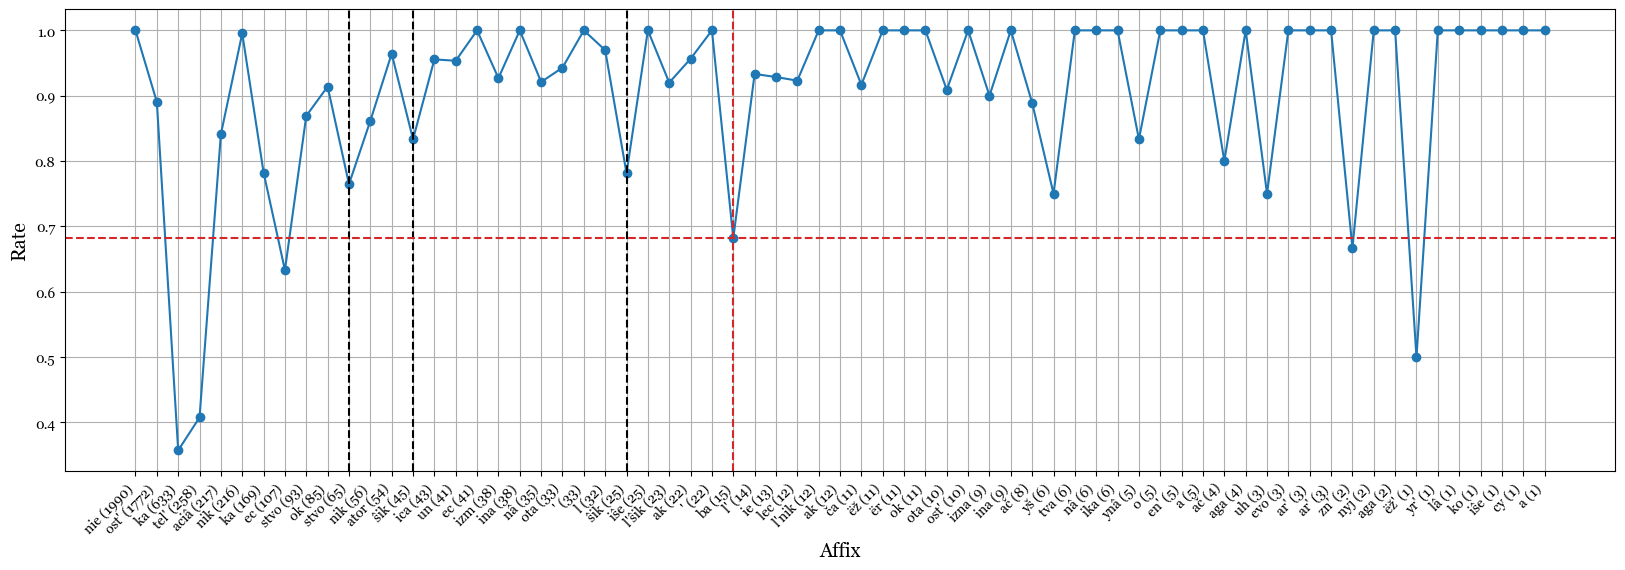

In [20]:
morphemes = [(v, k + f' ({v})') for k, v in cleanjcount.items() if k != 'prefix'] + [(v, k + f' ({v})') for k, v in cleanvcount.items() if k != 'prefix']
morphemes.sort(reverse=True)

ys = [1]
for i, m in enumerate(morphemes):
    if m != (1, 'a (1)'):
        ys.append(morphemes[i + 1][0] / m[0])
xs = list(range(len(morphemes)))

v1 = morphemes.index((15, 'ba (15)'))
v2 = morphemes.index((25, 'ŝik (25)'))
v3 = morphemes.index((45, 'ŝik (45)'))
v4 = morphemes.index((65, 'stvo (65)'))
plt.rcParams.update({'font.family': 'Georgia'})
plt.figure(figsize=(20, 6))
plt.plot(xs, ys, marker='o', linestyle='-', color=palette[0])
plt.xticks(xs, [m[1] for m in morphemes], rotation=45, ha='right')
plt.axvline(x=v1, color=palette[3], linestyle='--')
plt.axvline(x=v2, color='k', linestyle='--')
plt.axvline(x=v3, color='k', linestyle='--')
plt.axvline(x=v4, color='k', linestyle='--')
plt.axhline(y=ys[v1], color=palette[3], linestyle='--')
plt.xlabel('Affix', fontsize=14)
plt.ylabel('Rate', fontsize=14)
plt.grid()
plt.savefig('threshold.pdf', bbox_inches='tight')

In [21]:
verbalaffixes = {key: value for key, value in cleanvcount.items() if value >= 22}
v2n = v2n[v2n['affix'].map(verb2clean).isin(verbalaffixes)]
adjectivalaffixes = {key: value for key, value in cleanjcount.items() if value >= 22}
j2n = j2n[j2n['affix'].map(adj2clean).isin(adjectivalaffixes)]
len(v2n), len(j2n)

(3633, 2578)

In [22]:
verbalsorted = sorted(verbalaffixes, key=verbalaffixes.get, reverse=True)
adjectivalsorted = sorted(adjectivalaffixes, key=adjectivalaffixes.get, reverse=True)

In [23]:
verbclass = {'ние': 'AB', 'тель': 'B', 'ник': 'B', 'щик': 'B', 'льщик': 'B',
                'ация': 'AB', 'атор': 'B', 'ец': 'B', 'ок': 'AB', 'ство': 'AB',
                'ище': 'AB', 'ка': 'AB', 'ня': 'AB', 'ун': 'B', 'л': 'B', 'ь': 'AB'}
verbclass = {transliterate(key): value for key, value in verbclass.items()}

adjclass = {'ость': 'AB', 'изм': 'B', 'ство': 'AB', 'ка': 'B', 'ина': 'B', 'щик': 'B',
                'ник': 'B', 'ь': 'AB', 'ица': 'B', 'ец': 'B', 'ота': 'AB', 'ак': 'B'}
adjclass = {transliterate(key): value for key, value in adjclass.items()}

In [24]:
dif_v = [row['base_vec'] - row['der_vec'] for index, row in v2n.iterrows()]
dif_j = [row['base_vec'] - row['der_vec'] for index, row in j2n.iterrows()]

### Experiment 1

In [25]:
verbs = list(set(df[(df['base_pos'] == 'V')]['base']) - set(df[(df['der_pos'] == 'V')]['der']))
verbs_vectors = np.array(list(df[df['base'].isin(verbs) & df['base_vec'].notna()].drop_duplicates('base')['base_vec']))
verbs_centroid = verbs_vectors.mean(axis=0)

adjectives = list(set(df[(df['base_pos'] == 'J')]['base']) - set(df[(df['der_pos'] == 'J')]['der']))
adjectives_vectors = np.array(list(df[df['base'].isin(adjectives) & df['base_vec'].notna()].drop_duplicates('base')['base_vec']))
adjectives_centroid = adjectives_vectors.mean(axis=0)

nouns = list(set(df[(df['base_pos'] == 'N')]['base']) - set(df[(df['der_pos'] == 'N')]['der']))
nouns_vectors = np.array(list(df[df['base'].isin(nouns) & df['base_vec'].notna()].drop_duplicates('base')['base_vec']))
nouns_centroid = nouns_vectors.mean(axis=0)

In [26]:
def delta_mean(vectors, verbs=True):
    to_nouns = cdist(nouns_centroid.reshape(1, -1), vectors, metric='cosine').flatten()
    if verbs:
        to_bases = cdist(verbs_centroid.reshape(1, -1), vectors, metric='cosine').flatten()
    else:
        to_bases = cdist(adjectives_centroid.reshape(1, -1), vectors, metric='cosine').flatten()
    print(pg.ttest(to_bases - to_nouns, 0))
    return (to_bases - to_nouns).mean()

In [27]:
delta_mean(np.array(list(v2n['der_vec']))), delta_mean(np.array(list(j2n['der_vec'])), False)

                 T   dof alternative  p_val          CI95   cohen_d  power  \
T_test  110.779172  3632   two-sided    0.0  [0.08, 0.08]  1.837915    1.0   

       BF10  
T_test  inf  
               T   dof alternative         p_val            CI95   cohen_d  \
T_test -7.913703  2577   two-sided  3.676739e-15  [-0.01, -0.01]  0.155861   

        power       BF10  
T_test    1.0  5.859e+11  


(np.float64(0.08313019833532231), np.float64(-0.01072656389768363))

In [28]:
delta_mean(nouns_vectors), delta_mean(nouns_vectors, False)

                 T    dof alternative  p_val          CI95   cohen_d  power  \
T_test  206.069965  10042   two-sided    0.0  [0.11, 0.12]  2.056283    1.0   

       BF10  
T_test  inf  
                 T    dof alternative  p_val          CI95   cohen_d  power  \
T_test  164.292668  10042   two-sided    0.0  [0.08, 0.08]  1.639406    1.0   

       BF10  
T_test  inf  


(np.float64(0.114020531877068), np.float64(0.08276048502482893))

In [29]:
delta_mean(verbs_vectors), delta_mean(adjectives_vectors, False)

                 T   dof alternative  p_val            CI95   cohen_d  power  \
T_test -123.942138  2647   two-sided    0.0  [-0.14, -0.13]  2.408574    1.0   

       BF10  
T_test  inf  
              T   dof alternative  p_val           CI95   cohen_d  power BF10
T_test -83.6471  2302   two-sided    0.0  [-0.1, -0.09]  1.743026    1.0  inf


(np.float64(-0.13421858978722104), np.float64(-0.09558974407019005))

In [30]:
def ci_mean(data, test=False, alpha=0.05):
    n = len(data)
    mean = np.mean(data)
    se = np.std(data, ddof=1) / np.sqrt(n)
    t = t_statistics.ppf(1 - alpha/2, df=n-1)

    if not test:
        return mean - t*se, mean, mean + t*se

    ttest_result = pg.ttest(data, 0)
    pvalue = ttest_result['p_val'].iloc[0]
    cohen = ttest_result['cohen_d'].iloc[0]
    return mean - t*se, mean, mean + t*se, pvalue, cohen

def plot_intervals(df, labels, axes, file, zero=False):
    label_order = {label: idx for idx, label in enumerate(labels)}

    df_sorted = df.copy()
    col = axes[0].lower()
    df_sorted['order'] = df_sorted[col].map(label_order)
    df_sorted = df_sorted.sort_values('order').reset_index(drop=True)
    
    x = np.arange(1, len(df_sorted) + 1)
    mins = df_sorted['low'].values
    means = df_sorted['mean'].values
    maxs = df_sorted['high'].values
    
    plt.figure(figsize=(15, 6))
    
    for xi, lo, hi in zip(x, mins, maxs):
        plt.plot([xi, xi], [lo, hi], color='k')
        plt.plot([xi-0.01, xi+0.01], [lo, lo], color='k')
        plt.plot([xi-0.01, xi+0.01], [hi, hi], color='k')
    
    plt.plot(x, means, marker='o', linestyle='-', color=palette[0])
    if zero:
        plt.axhline(y=0, color=palette[3], linestyle='--')
    
    plt.xticks(x, labels)
    plt.xlabel(axes[0], fontsize=12)
    plt.ylabel(axes[1], fontsize=12)
    plt.title('Confidence Intervals', fontsize=14, fontweight='bold')
    plt.grid()
    plt.savefig(file, bbox_inches='tight')

In [31]:
deltas_j = {'value': [], 'class': [], 'affix': []}
for index, row in j2n.iterrows():
    a = adj2clean[row['affix']]
    deltas_j['affix'].append(a)
    c = adjclass[a]
    deltas_j['class'].append(c)
    d = cosine(adjectives_centroid, row['der_vec']) - cosine(nouns_centroid, row['der_vec'])
    deltas_j['value'].append(d)
deltas_j = pd.DataFrame(deltas_j)

In [32]:
delta_class_j = deltas_j.groupby('class')['value'].apply(
    lambda group: pd.Series(ci_mean(group.tolist(), True), index=['low', 'mean', 'high', 'p', 'cohen'])
    ).unstack().reset_index()
delta_class_j

,class,low,mean,high,p,cohen
0,AB,-0.044118,-0.042252,-0.040387,5.013502e-297,1.013821
1,B,0.077734,0.081263,0.084792,6.762352e-204,1.762800


In [33]:
pg.pairwise_tests(data=deltas_j, dv='value', between='class', padjust='holm')

,Contrast,A,B,Paired,Parametric,T,dof,alternative,p_unc,BF10,hedges
0,class,AB,B,False,True,-60.746415,1048.441158,two-sided,0.0,inf,-2.881829


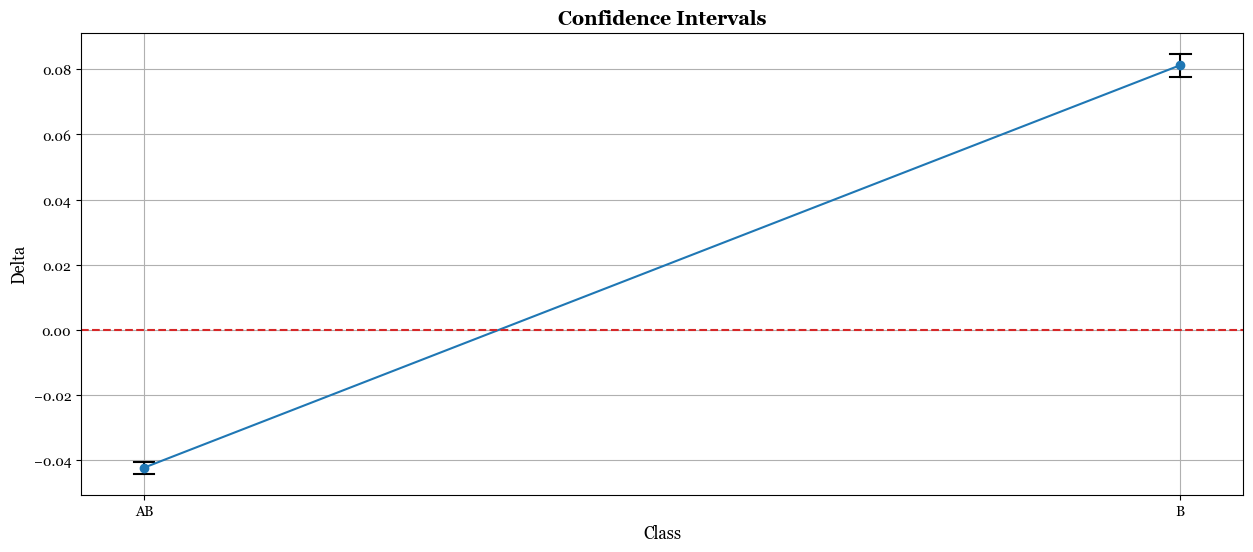

In [34]:
plot_intervals(delta_class_j, ['AB', 'B'], ['Class', 'Delta'], 'ex1_CLS_J.pdf', True)

In [35]:
deltas_v = {'value': [], 'class': [], 'affix': []}
for index, row in v2n.iterrows():
    a = verb2clean[row['affix']]
    deltas_v['affix'].append(a)
    c = verbclass[a]
    deltas_v['class'].append(c)
    d = cosine(verbs_centroid, row['der_vec']) - cosine(nouns_centroid, row['der_vec'])
    deltas_v['value'].append(d)
deltas_v = pd.DataFrame(deltas_v)

In [36]:
delta_class_v = deltas_v.groupby('class')['value'].apply(
    lambda group: pd.Series(ci_mean(group.tolist(), True), index=['low', 'mean', 'high', 'p', 'cohen'])
    ).unstack().reset_index()
delta_class_v

,class,low,mean,high,p,cohen
0,AB,0.077304,0.078846,0.080388,0.000000e+00,1.805232
1,B,0.103266,0.107145,0.111024,9.186188e-223,2.313716


In [37]:
pg.pairwise_tests(data=deltas_v, dv='value', between='class', padjust='holm')

,Contrast,A,B,Paired,Parametric,T,dof,alternative,p_unc,BF10,hedges
0,class,AB,B,False,True,-13.313903,733.779691,two-sided,2.212231e-36,1.162e+36,-0.641793


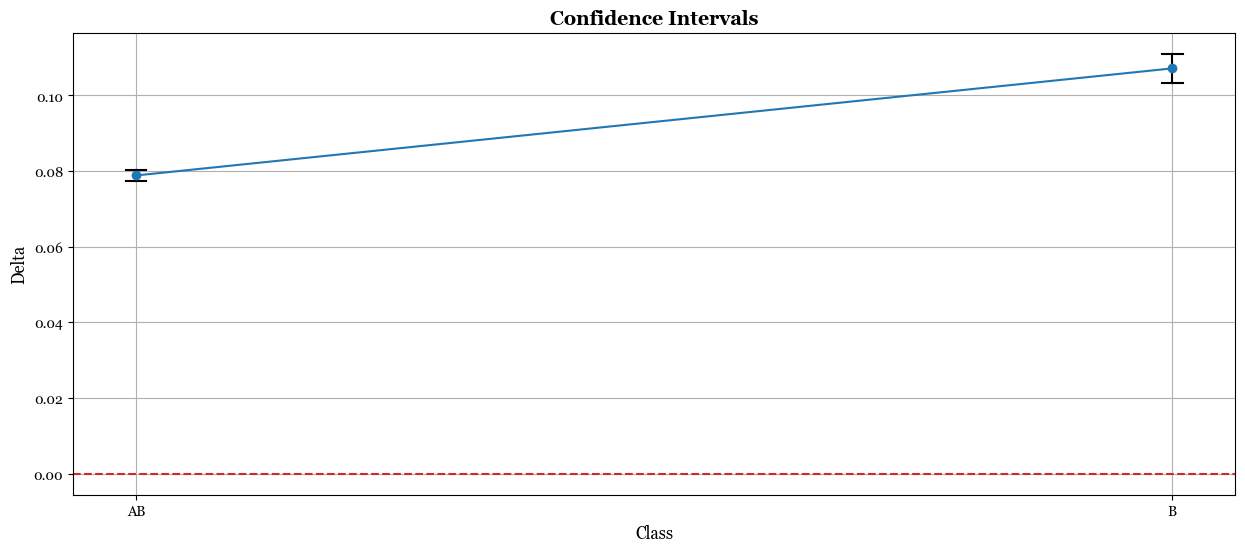

In [38]:
plot_intervals(delta_class_v, ['AB', 'B'], ['Class', 'Delta'], 'ex1_CLS_V.pdf', True)

In [39]:
delta_affix_j = deltas_j.groupby('affix')['value'].apply(
    lambda group: pd.Series(ci_mean(group.tolist(), True), index=['low', 'mean', 'high', 'p', 'cohen'])
    ).unstack().reset_index()
delta_affix_j

,affix,low,mean,high,p,cohen
0,',0.036469,0.063640,0.090812,8.136838e-05,1.038455
1,ak,0.048739,0.066939,0.085139,1.678451e-07,1.630733
2,ec,0.080300,0.087203,0.094106,2.534710e-46,2.421213
3,ica,0.063188,0.077728,0.092267,1.108052e-13,1.645284
4,ina,0.042962,0.056268,0.069575,2.595837e-10,1.389892
5,izm,-0.002329,0.006154,0.014637,1.500470e-01,0.238446
6,ka,0.086231,0.092650,0.099069,3.123811e-66,2.191871
7,nik,0.079728,0.085570,0.091412,6.429772e-76,1.964444
8,ost',-0.048329,-0.046558,-0.044787,0.000000e+00,1.224609
9,ota,-0.022800,-0.008497,0.005805,2.350661e-01,0.210669


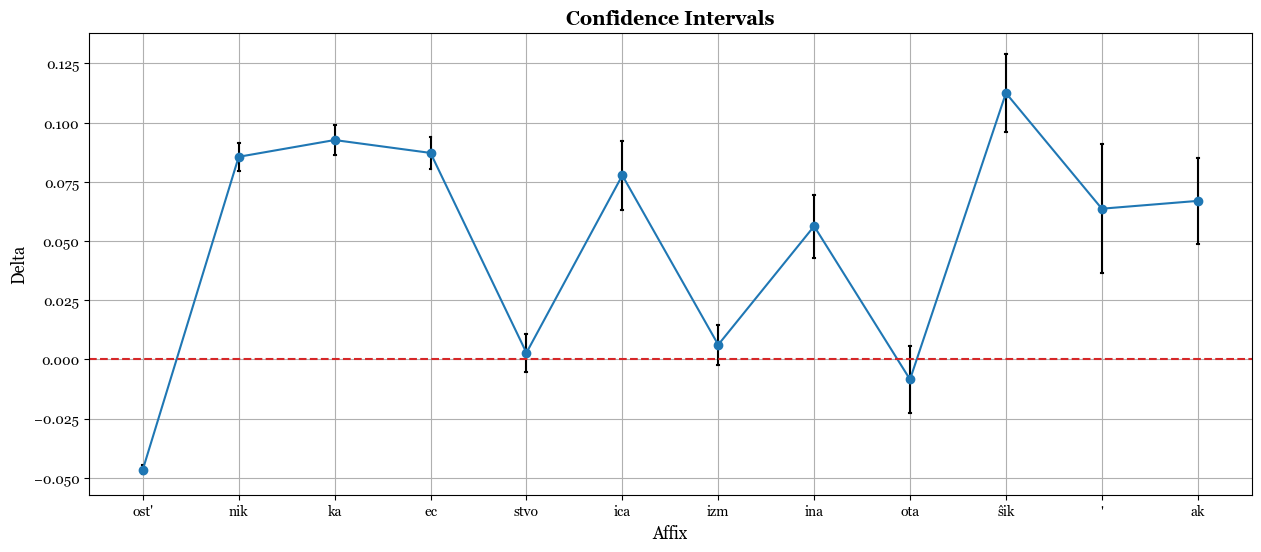

In [40]:
plot_intervals(delta_affix_j, adjectivalsorted, ['Affix', 'Delta'], 'ex1_AFX_J.pdf', True)

In [41]:
delta_affix_v = deltas_v.groupby('affix')['value'].apply(
    lambda group: pd.Series(ci_mean(group.tolist(), True), index=['low', 'mean', 'high', 'p', 'cohen'])
    ).unstack().reset_index()
delta_affix_v

,affix,low,mean,high,p,cohen
0,',0.060413,0.073991,0.087569,1.662220e-12,1.932235
1,aciâ,0.129206,0.133978,0.138750,1.510956e-129,3.756616
2,ator,0.152410,0.163625,0.174840,2.175478e-34,3.982195
3,ec,0.075717,0.085346,0.094975,1.037787e-20,2.797607
4,iŝe,0.057145,0.072342,0.087539,6.932729e-10,1.964982
5,ka,0.085440,0.088666,0.091891,7.102029e-239,2.145587
6,l,0.028195,0.043198,0.058201,1.764983e-06,1.038106
7,l'ŝik,0.127162,0.141227,0.155292,5.720137e-16,4.342124
8,nie,0.068763,0.070552,0.072342,0.000000e+00,1.733193
9,nik,0.075503,0.086065,0.096627,9.440411e-23,2.182208


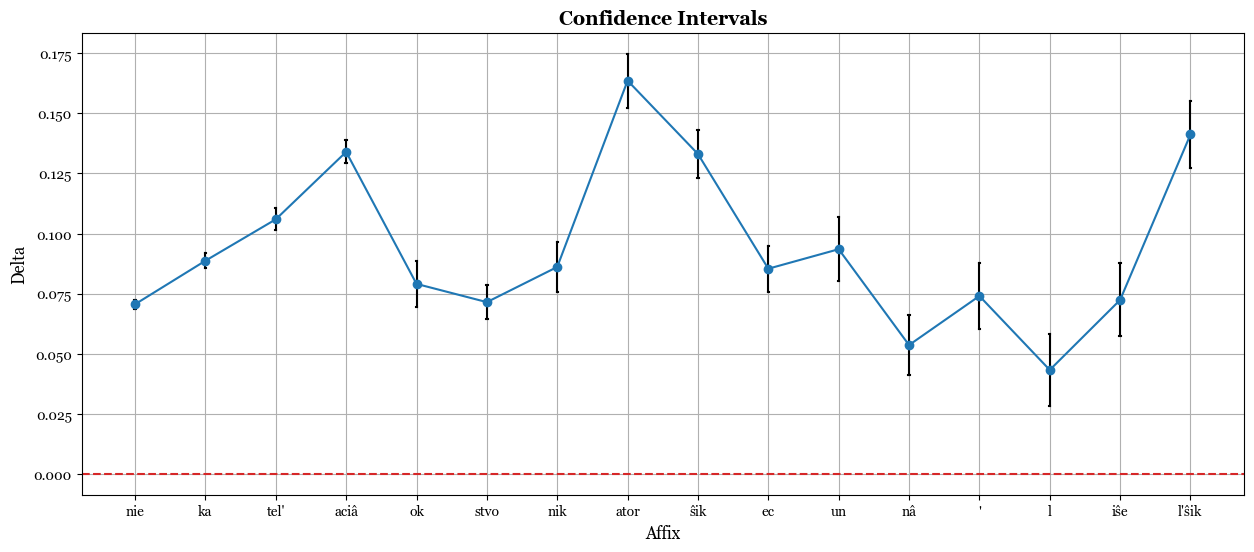

In [42]:
plot_intervals(delta_affix_v, verbalsorted, ['Affix', 'Delta'], 'ex1_AFX_V.pdf', True)

### Experiment 2

In [43]:
dist2base_v = [cosine(row['base_vec'], row['der_vec']).astype(float) for index, row in v2n.iterrows()]
dist2base_j = [cosine(row['base_vec'], row['der_vec']).astype(float) for index, row in j2n.iterrows()]

In [44]:
print(np.mean(dist2base_v), np.mean(dist2base_j))
pg.ttest(dist2base_v, dist2base_j, correction=False)

0.3077253131147196 0.2546289498904031


,T,dof,alternative,p_val,CI95,cohen_d,power,BF10
T_test,15.936265,6209,two-sided,4.537839e-56,"[0.05, 0.06]",0.410387,1.0,2.487e+52


In [45]:
base_j = {'value': [], 'class': [], 'affix': []}
for index, row in j2n.iterrows():
    a = adj2clean[row['affix']]
    base_j['affix'].append(a)
    c = adjclass[a]
    base_j['class'].append(c)
    d = cosine(row['base_vec'], row['der_vec'])
    base_j['value'].append(d)
base_j = pd.DataFrame(base_j)

In [46]:
base_class_j = base_j.groupby('class')['value'].apply(
    lambda group: pd.Series(ci_mean(group.tolist()), index=['low', 'mean', 'high'])
    ).unstack().reset_index()
base_class_j

,class,low,mean,high
0,AB,0.238235,0.243328,0.248420
1,B,0.276433,0.287605,0.298778


In [47]:
pg.pairwise_tests(data=base_j, dv='value', between='class', padjust='holm')

,Contrast,A,B,Paired,Parametric,T,dof,alternative,p_unc,BF10,hedges
0,class,AB,B,False,True,-7.079467,945.086452,two-sided,2.820853e-12,2.564e+09,-0.360506


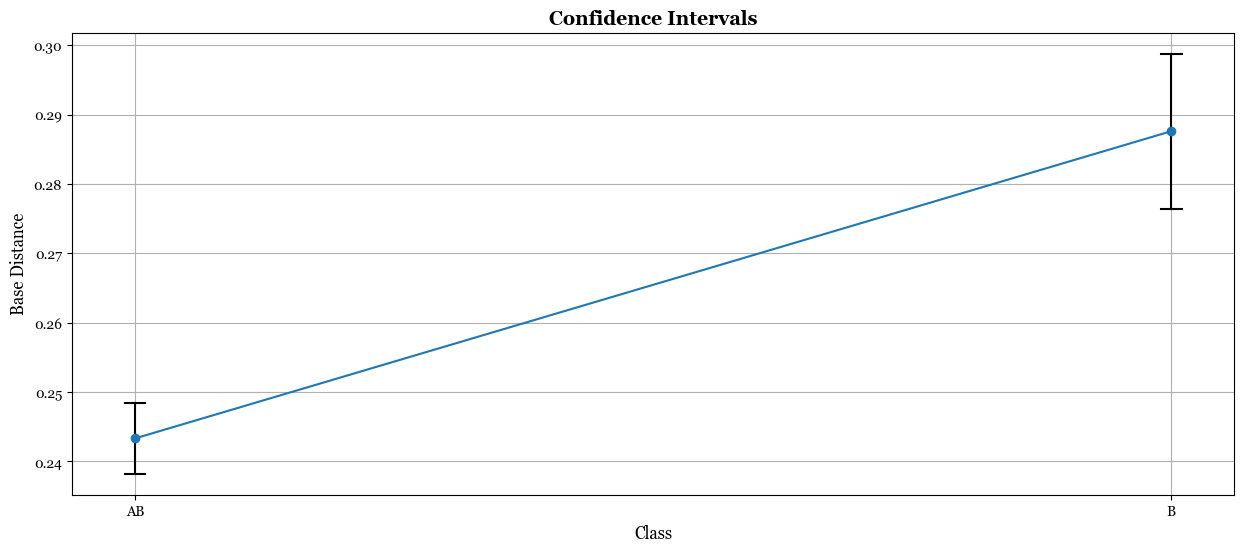

In [48]:
plot_intervals(base_class_j, ['AB', 'B'], ['Class', 'Base Distance'], 'ex2_CLS_J.pdf')

In [49]:
base_v = {'value': [], 'class': [], 'affix': []}
for index, row in v2n.iterrows():
    a = verb2clean[row['affix']]
    base_v['affix'].append(a)
    c = verbclass[a]
    base_v['class'].append(c)
    d = cosine(row['base_vec'], row['der_vec'])
    base_v['value'].append(d)
base_v = pd.DataFrame(base_v)

In [50]:
base_class_v = base_v.groupby('class')['value'].apply(
    lambda group: pd.Series(ci_mean(group.tolist()), index=['low', 'mean', 'high'])
    ).unstack().reset_index()
base_class_v

,class,low,mean,high
0,AB,0.295658,0.300246,0.304833
1,B,0.337803,0.349651,0.361499


In [51]:
pg.pairwise_tests(data=base_v, dv='value', between='class', padjust='holm')

,Contrast,A,B,Paired,Parametric,T,dof,alternative,p_unc,BF10,hedges
0,class,AB,B,False,True,-7.636472,723.717365,two-sided,7.076694e-14,1.537e+11,-0.374997


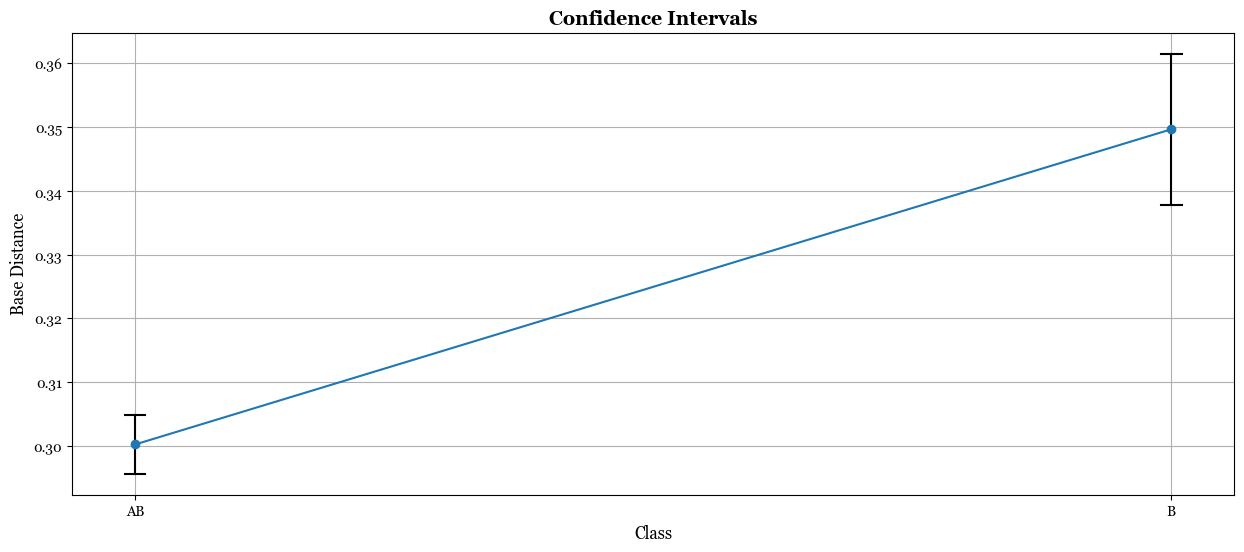

In [52]:
plot_intervals(base_class_v, ['AB', 'B'], ['Class', 'Base Distance'], 'ex2_CLS_V.pdf')

In [53]:
base_affix_j = base_j.groupby('affix')['value'].apply(
    lambda group: pd.Series(ci_mean(group.tolist()), index=['low', 'mean', 'high'])
    ).unstack().reset_index()
base_affix_j

,affix,low,mean,high
0,',0.293836,0.378327,0.462819
1,ak,0.336913,0.397064,0.457216
2,ec,0.299367,0.329335,0.359304
3,ica,0.265799,0.308561,0.351322
4,ina,0.324917,0.379560,0.434204
5,izm,0.261574,0.308998,0.356422
6,ka,0.248473,0.269599,0.290726
7,nik,0.224634,0.241334,0.258033
8,ost',0.228331,0.233223,0.238116
9,ota,0.339580,0.378855,0.418131


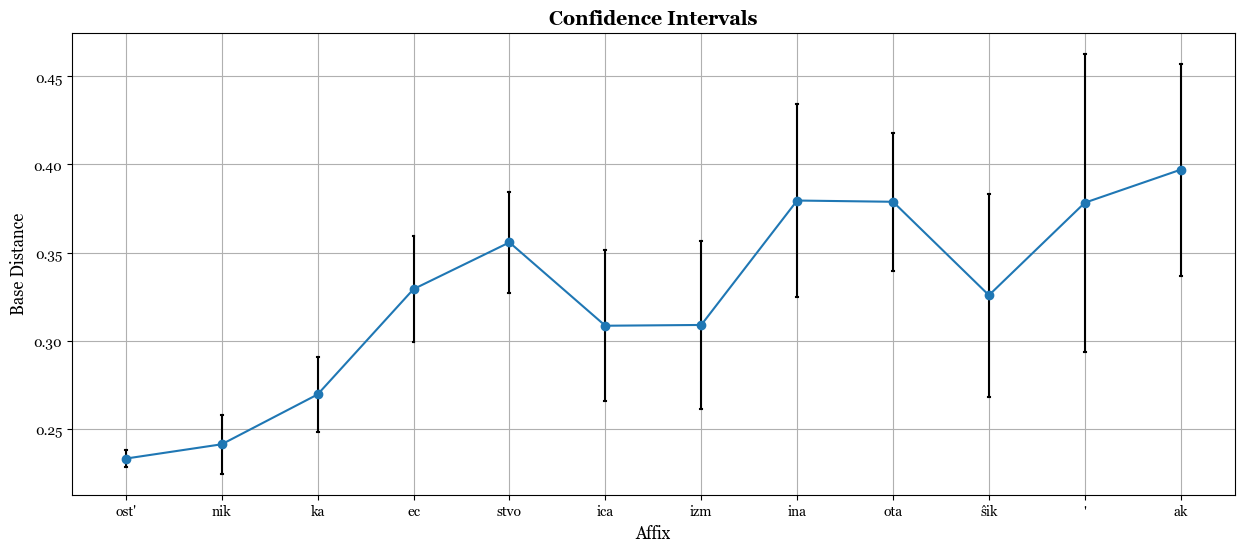

In [54]:
plot_intervals(base_affix_j, adjectivalsorted, ['Affix', 'Base Distance'], 'ex2_AFX_J.pdf')

In [55]:
base_affix_v = base_v.groupby('affix')['value'].apply(
    lambda group: pd.Series(ci_mean(group.tolist()), index=['low', 'mean', 'high'])
    ).unstack().reset_index()
base_affix_v

,affix,low,mean,high
0,',0.262846,0.312630,0.362414
1,aciâ,0.255246,0.265913,0.276580
2,ator,0.310001,0.335962,0.361924
3,ec,0.449260,0.499026,0.548793
4,iŝe,0.423041,0.486678,0.550315
5,ka,0.306671,0.317511,0.328350
6,l,0.304658,0.349638,0.394618
7,l'ŝik,0.402320,0.458018,0.513717
8,nie,0.279744,0.285044,0.290345
9,nik,0.379940,0.417754,0.455569


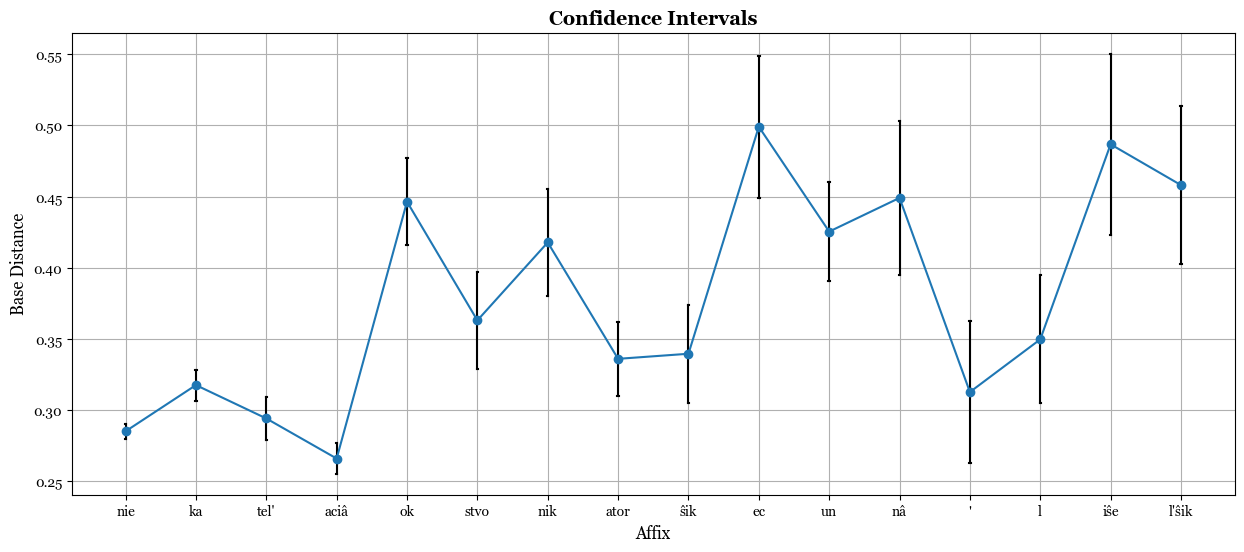

In [56]:
plot_intervals(base_affix_v, verbalsorted, ['Affix', 'Base Distance'], 'ex2_AFX_V.pdf')

### Experiment 3

In [57]:
def cluster_dist(vectors):
    vectors = np.array(vectors)
    pairwise_dist = pdist(vectors, metric='cosine')
    centroid = vectors.mean(axis=0)
    centroid_dist = 1 - np.dot(vectors, centroid) / (np.linalg.norm(vectors, axis=1) * np.linalg.norm(centroid))
    return pairwise_dist, centroid_dist.astype(float)

#### Words

In [58]:
pairwise_dv, centroid_dv = cluster_dist(list(v2n['der_vec']))
pairwise_dj, centroid_dj = cluster_dist(list(j2n['der_vec']))
print(np.mean(pairwise_dv), np.mean(pairwise_dj))
print(pg.ttest(pairwise_dv, pairwise_dj, correction=False))
print(np.mean(centroid_dv), np.mean(centroid_dj))
print(pg.ttest(centroid_dv, centroid_dj, correction=False))

0.7377585836286487 0.6675754690310546
                 T      dof alternative  p_val          CI95   cohen_d  power  \
T_test  798.553914  9919279   two-sided    0.0  [0.07, 0.07]  0.537242    1.0   

       BF10  
T_test  inf  
0.4877529376930617 0.42323988974325594
                T   dof alternative         p_val          CI95   cohen_d  \
T_test  20.342101  6209   two-sided  4.151862e-89  [0.06, 0.07]  0.523845   

        power       BF10  
T_test    1.0  1.887e+85  


In [59]:
vec_j = {'value': [], 'class': [], 'affix': []}
for index, row in j2n.iterrows():
    a = adj2clean[row['affix']]
    vec_j['affix'].append(a)
    c = adjclass[a]
    vec_j['class'].append(c)
    vec_j['value'].append(row['der_vec'])
vec_j = pd.DataFrame(vec_j)

vec_v = {'value': [], 'class': [], 'affix': []}
for index, row in v2n.iterrows():
    a = verb2clean[row['affix']]
    vec_v['affix'].append(a)
    c = verbclass[a]
    vec_v['class'].append(c)
    vec_v['value'].append(row['der_vec'])
vec_v = pd.DataFrame(vec_v)

In [60]:
result = vec_j.groupby('class')['value'].apply(lambda g: cluster_dist(g.tolist()))

pair_class_j = pd.DataFrame([
    {'class': cls, 'value': x}
    for cls, (pairs, _) in result.items()
    for x in pairs
])

cent_class_j = pd.DataFrame([
    {'class': cls, 'value': x}
    for cls, (_, centers) in result.items()
    for x in centers
])

result = vec_v.groupby('class')['value'].apply(lambda g: cluster_dist(g.tolist()))

pair_class_v = pd.DataFrame([
    {'class': cls, 'value': x}
    for cls, (pairs, _) in result.items()
    for x in pairs
])

cent_class_v = pd.DataFrame([
    {'class': cls, 'value': x}
    for cls, (_, centers) in result.items()
    for x in centers
])

In [61]:
pair_class_j_w = pair_class_j.groupby('class')['value'].apply(
    lambda group: pd.Series(ci_mean(group.tolist()), index=['low', 'mean', 'high'])
    ).unstack().reset_index()
pair_class_j_w

,class,low,mean,high
0,AB,0.562810,0.562976,0.563143
1,B,0.750268,0.750690,0.751113


In [62]:
pg.pairwise_tests(data=pair_class_j, dv='value', between='class', padjust='holm')

,Contrast,A,B,Paired,Parametric,T,dof,alternative,p_unc,BF10,hedges
0,class,AB,B,False,True,-809.831125,287916.156592,two-sided,0.0,inf,-1.646714


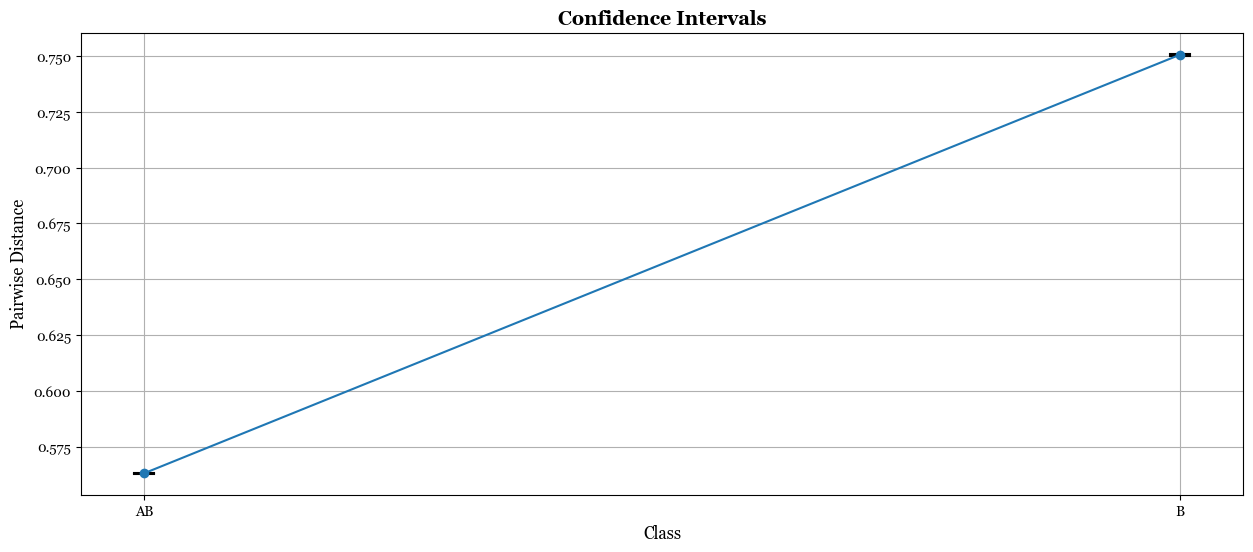

In [63]:
plot_intervals(pair_class_j_w, ['AB', 'B'], ['Class', 'Pairwise Distance'], 'ex3_CLS_J_DN_PD.pdf')

In [64]:
pair_class_v_w = pair_class_v.groupby('class')['value'].apply(
    lambda group: pd.Series(ci_mean(group.tolist()), index=['low', 'mean', 'high'])
    ).unstack().reset_index()
pair_class_v_w

,class,low,mean,high
0,AB,0.714906,0.715010,0.715114
1,B,0.713468,0.713971,0.714475


In [65]:
pg.pairwise_tests(data=pair_class_v, dv='value', between='class', padjust='holm')

,Contrast,A,B,Paired,Parametric,T,dof,alternative,p_unc,BF10,hedges
0,class,AB,B,False,True,3.959192,164011.989552,two-sided,0.000075,7.475,0.00905


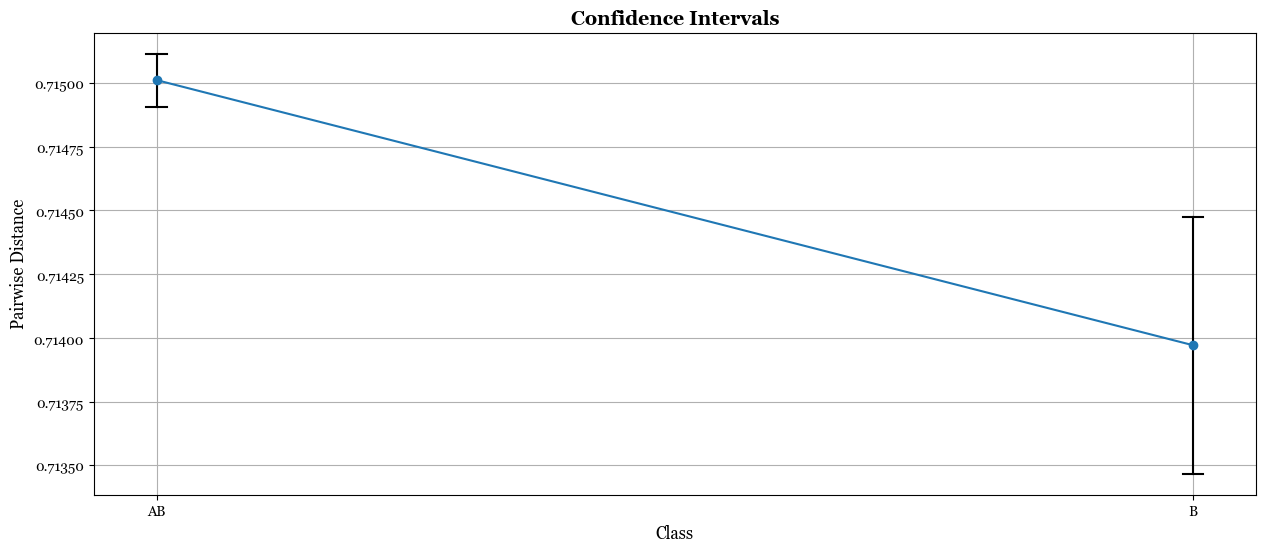

In [66]:
plot_intervals(pair_class_v_w, ['AB', 'B'], ['Class', 'Pairwise Distance'], 'ex3_CLS_V_DN_PD.pdf')

In [67]:
cent_class_j_w = cent_class_j.groupby('class')['value'].apply(
    lambda group: pd.Series(ci_mean(group.tolist()), index=['low', 'mean', 'high'])
    ).unstack().reset_index()
cent_class_j_w

,class,low,mean,high
0,AB,0.334253,0.338724,0.343195
1,B,0.495083,0.499676,0.504269


In [68]:
pg.pairwise_tests(data=cent_class_j, dv='value', between='class', padjust='holm')

,Contrast,A,B,Paired,Parametric,T,dof,alternative,p_unc,BF10,hedges
0,class,AB,B,False,True,-49.277678,1908.612415,two-sided,0.0,inf,-1.760634


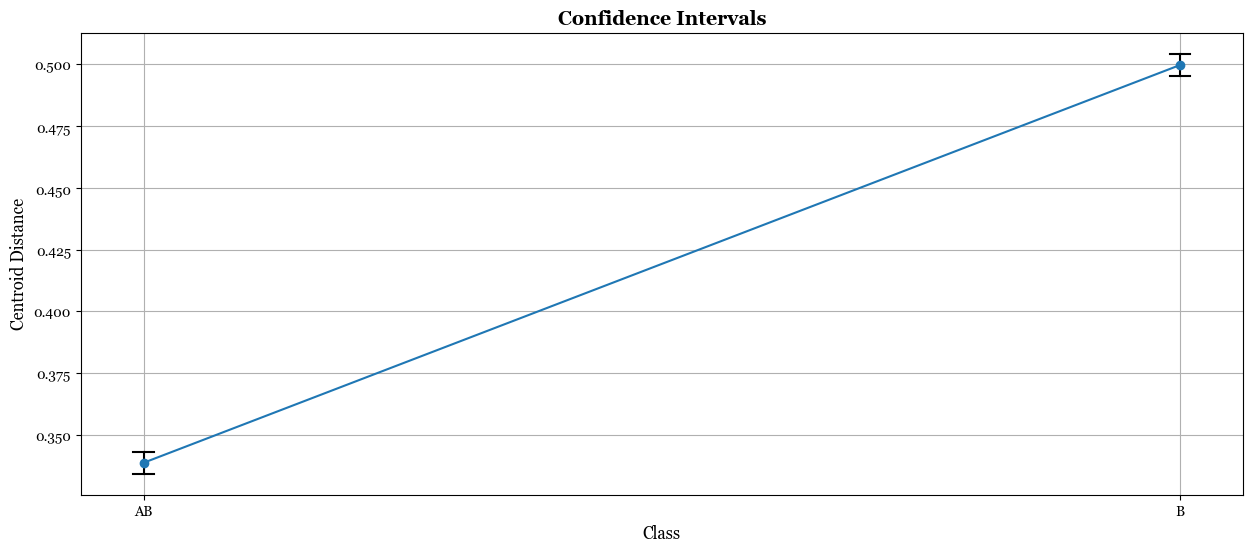

In [69]:
plot_intervals(cent_class_j_w, ['AB', 'B'], ['Class', 'Centroid Distance'], 'ex3_CLS_J_DN_CD.pdf')

In [70]:
cent_class_v_w = cent_class_v.groupby('class')['value'].apply(
    lambda group: pd.Series(ci_mean(group.tolist()), index=['low', 'mean', 'high'])
    ).unstack().reset_index()
cent_class_v_w

,class,low,mean,high
0,AB,0.462389,0.465978,0.469567
1,B,0.458404,0.464049,0.469695


In [71]:
pg.pairwise_tests(data=cent_class_v, dv='value', between='class', padjust='holm')

,Contrast,A,B,Paired,Parametric,T,dof,alternative,p_unc,BF10,hedges
0,class,AB,B,False,True,0.566136,1053.826237,two-sided,0.571422,0.061,0.019835


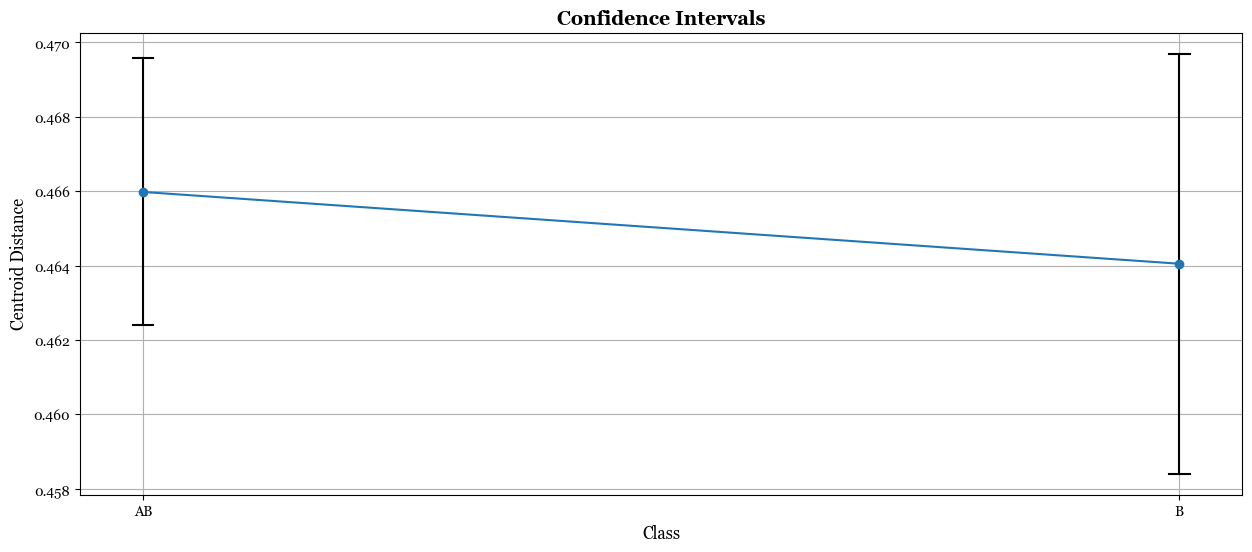

In [72]:
plot_intervals(cent_class_v_w, ['AB', 'B'], ['Class', 'Centroid Distance'], 'ex3_CLS_V_DN_CD.pdf')

In [73]:
result = vec_j.groupby('affix')['value'].apply(lambda g: cluster_dist(g.tolist()))

pair_affix_j = pd.DataFrame([
    {'affix': cls, 'value': x}
    for cls, (pairs, _) in result.items()
    for x in pairs
])

cent_affix_j = pd.DataFrame([
    {'affix': cls, 'value': x}
    for cls, (_, centers) in result.items()
    for x in centers
])

result = vec_v.groupby('affix')['value'].apply(lambda g: cluster_dist(g.tolist()))

pair_affix_v = pd.DataFrame([
    {'affix': cls, 'value': x}
    for cls, (pairs, _) in result.items()
    for x in pairs
])

cent_affix_v = pd.DataFrame([
    {'affix': cls, 'value': x}
    for cls, (_, centers) in result.items()
    for x in centers
])

In [74]:
pair_affix_j_w = pair_affix_j.groupby('affix')['value'].apply(
    lambda group: pd.Series(ci_mean(group.tolist()), index=['low', 'mean', 'high'])
    ).unstack().reset_index()
pair_affix_j_w

,affix,low,mean,high
0,',0.769425,0.781647,0.793869
1,ak,0.678043,0.690289,0.702534
2,ec,0.646235,0.649301,0.652367
3,ica,0.689346,0.697492,0.705638
4,ina,0.716770,0.725744,0.734718
5,izm,0.377488,0.384446,0.391403
6,ka,0.693934,0.695535,0.697135
7,nik,0.716166,0.717411,0.718655
8,ost',0.540192,0.540348,0.540505
9,ota,0.656102,0.665839,0.675575


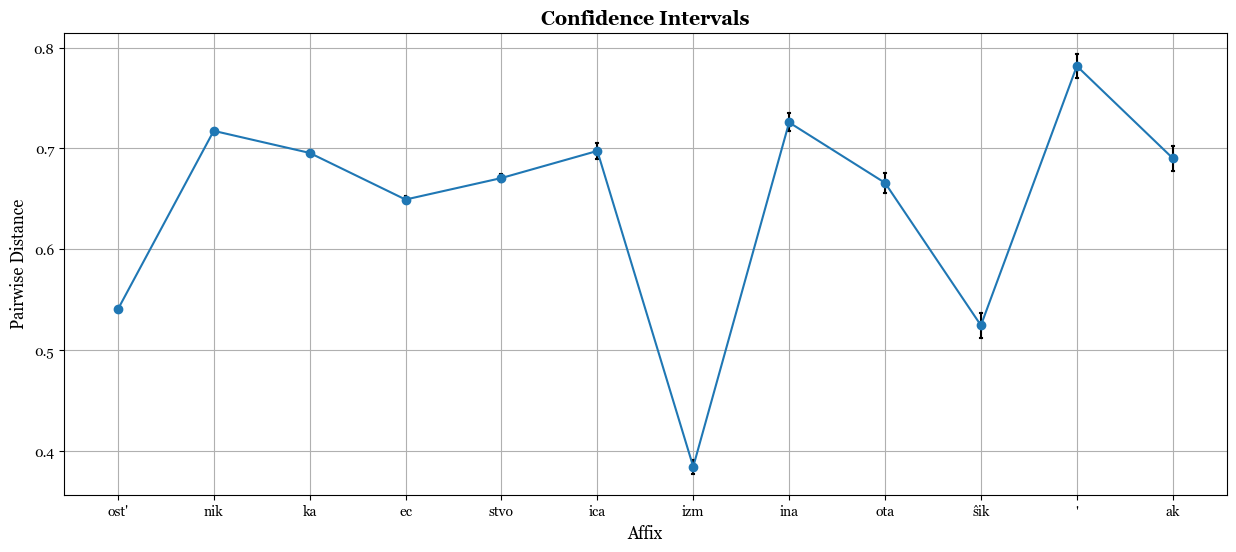

In [75]:
plot_intervals(pair_affix_j_w, adjectivalsorted, ['Affix', 'Pairwise Distance'], 'ex3_AFX_J_DN_PD.pdf')

In [76]:
cent_affix_j_w = cent_affix_j.groupby('affix')['value'].apply(
    lambda group: pd.Series(ci_mean(group.tolist()), index=['low', 'mean', 'high'])
    ).unstack().reset_index()
cent_affix_j_w

,affix,low,mean,high
0,',0.461427,0.496380,0.531332
1,ak,0.392533,0.416238,0.439942
2,ec,0.386090,0.402802,0.419513
3,ica,0.402825,0.435615,0.468404
4,ina,0.431229,0.458683,0.486138
5,izm,0.186831,0.209125,0.231418
6,ka,0.432249,0.444571,0.456893
7,nik,0.456322,0.465368,0.474415
8,ost',0.318139,0.321823,0.325507
9,ota,0.377541,0.405031,0.432521


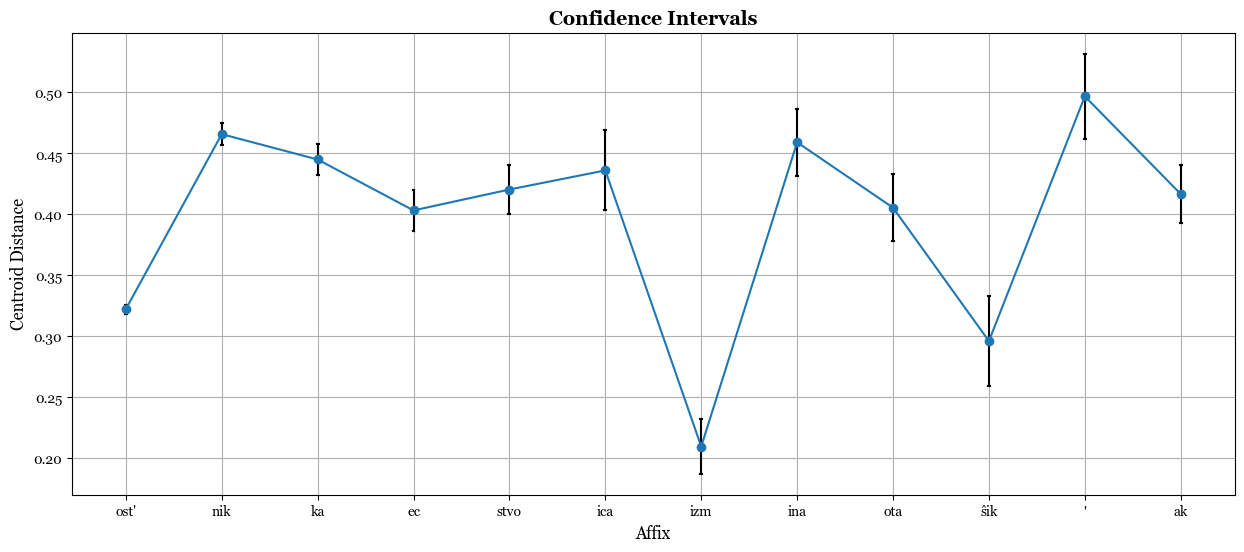

In [77]:
plot_intervals(cent_affix_j_w, adjectivalsorted, ['Affix', 'Centroid Distance'], 'ex3_AFX_J_DN_CD.pdf')

In [78]:
pair_affix_v_w = pair_affix_v.groupby('affix')['value'].apply(
    lambda group: pd.Series(ci_mean(group.tolist()), index=['low', 'mean', 'high'])
    ).unstack().reset_index()
pair_affix_v_w

,affix,low,mean,high
0,',0.767458,0.777426,0.787394
1,aciâ,0.568387,0.569939,0.571491
2,ator,0.582713,0.588593,0.594473
3,ec,0.680157,0.687268,0.694379
4,iŝe,0.630622,0.642784,0.654946
5,ka,0.726679,0.727118,0.727556
6,l,0.709204,0.718268,0.727331
7,l'ŝik,0.403867,0.416555,0.429242
8,nie,0.661509,0.661657,0.661806
9,nik,0.688973,0.694032,0.699091


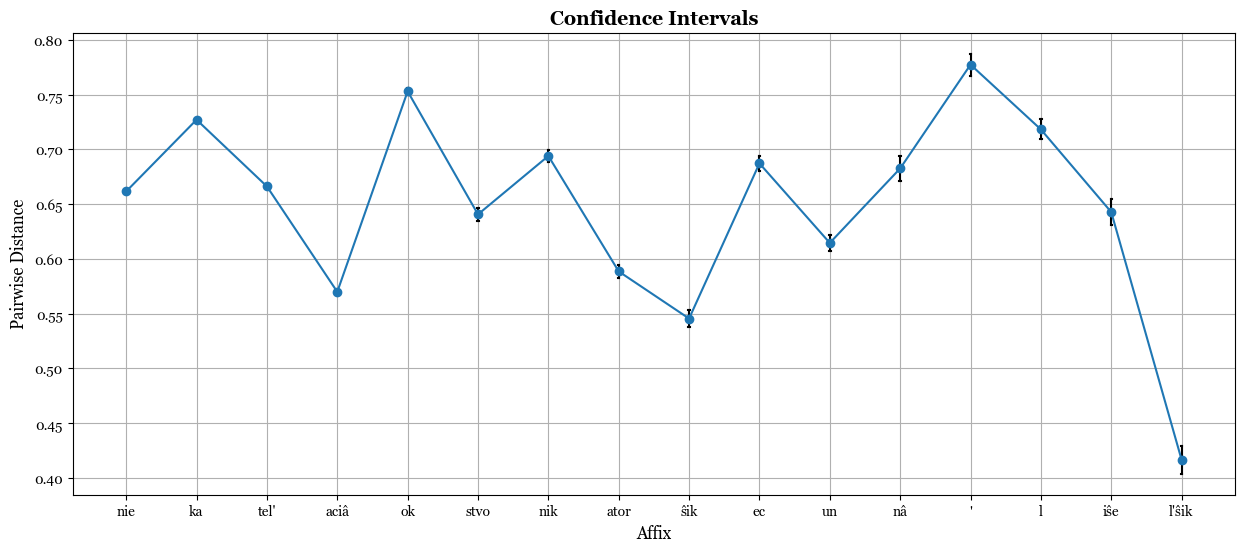

In [79]:
plot_intervals(pair_affix_v_w, verbalsorted, ['Affix', 'Pairwise Distance'], 'ex3_AFX_V_DN_PD.pdf')

In [80]:
cent_affix_v_w = cent_affix_v.groupby('affix')['value'].apply(
    lambda group: pd.Series(ci_mean(group.tolist()), index=['low', 'mean', 'high'])
    ).unstack().reset_index()
cent_affix_v_w

,affix,low,mean,high
0,',0.479537,0.503961,0.528384
1,aciâ,0.328706,0.342272,0.355837
2,ator,0.329087,0.350293,0.371498
3,ec,0.405028,0.426101,0.447175
4,iŝe,0.347956,0.381478,0.415001
5,ka,0.470706,0.476635,0.482564
6,l,0.417820,0.448968,0.480116
7,l'ŝik,0.194036,0.224489,0.254942
8,nie,0.414301,0.418066,0.421831
9,nik,0.414844,0.435893,0.456943


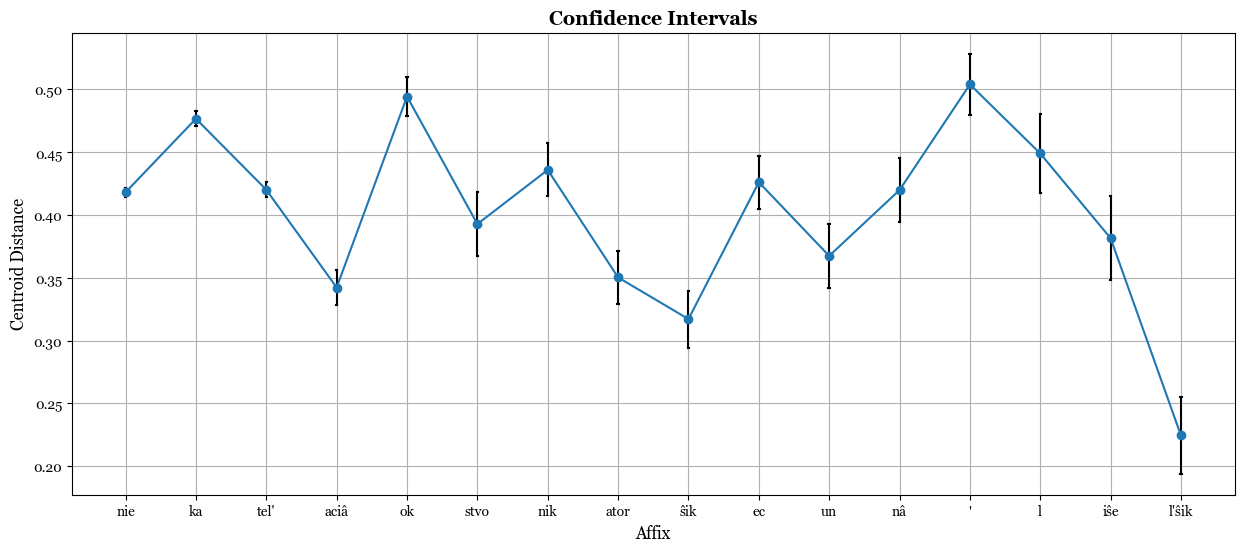

In [81]:
plot_intervals(cent_affix_v_w, verbalsorted, ['Affix', 'Centroid Distance'], 'ex3_AFX_V_DN_CD.pdf')

#### Differences

In [82]:
pairwise_dv, centroid_dv = cluster_dist(dif_v)
pairwise_dj, centroid_dj = cluster_dist(dif_j)
print(np.mean(pairwise_dv), np.mean(pairwise_dj))
print(pg.ttest(pairwise_dv, pairwise_dj, correction=False))
print(np.mean(centroid_dv), np.mean(centroid_dj))
print(pg.ttest(centroid_dv, centroid_dj, correction=False))

0.7368879051941931 0.698832903586853
                 T      dof alternative  p_val          CI95   cohen_d  power  \
T_test  298.028531  9919279   two-sided    0.0  [0.04, 0.04]  0.200504    1.0   

       BF10  
T_test  inf  
0.48712517561874474 0.4512036401833371
               T   dof alternative         p_val          CI95   cohen_d  \
T_test  6.728335  6209   two-sided  1.869752e-11  [0.03, 0.05]  0.173266   

           power       BF10  
T_test  0.999999  1.713e+08  


In [83]:
vec_j = {'value': [], 'class': [], 'affix': []}
for index, row in j2n.iterrows():
    a = adj2clean[row['affix']]
    vec_j['affix'].append(a)
    c = adjclass[a]
    vec_j['class'].append(c)
    vec_j['value'].append(row['base_vec'] - row['der_vec'])
vec_j = pd.DataFrame(vec_j)

vec_v = {'value': [], 'class': [], 'affix': []}
for index, row in v2n.iterrows():
    a = verb2clean[row['affix']]
    vec_v['affix'].append(a)
    c = verbclass[a]
    vec_v['class'].append(c)
    vec_v['value'].append(row['base_vec'] - row['der_vec'])
vec_v = pd.DataFrame(vec_v)

In [84]:
result = vec_j.groupby('class')['value'].apply(lambda g: cluster_dist(g.tolist()))

pair_class_j = pd.DataFrame([
    {'class': cls, 'value': x}
    for cls, (pairs, _) in result.items()
    for x in pairs
])

cent_class_j = pd.DataFrame([
    {'class': cls, 'value': x}
    for cls, (_, centers) in result.items()
    for x in centers
])

result = vec_v.groupby('class')['value'].apply(lambda g: cluster_dist(g.tolist()))

pair_class_v = pd.DataFrame([
    {'class': cls, 'value': x}
    for cls, (pairs, _) in result.items()
    for x in pairs
])

cent_class_v = pd.DataFrame([
    {'class': cls, 'value': x}
    for cls, (_, centers) in result.items()
    for x in centers
])

In [85]:
pair_class_j_d = pair_class_j.groupby('class')['value'].apply(
    lambda group: pd.Series(ci_mean(group.tolist()), index=['low', 'mean', 'high'])
    ).unstack().reset_index()
pair_class_j_d

,class,low,mean,high
0,AB,0.537410,0.537668,0.537926
1,B,0.816361,0.816924,0.817487


In [86]:
pg.pairwise_tests(data=pair_class_j, dv='value', between='class', padjust='holm')

,Contrast,A,B,Paired,Parametric,T,dof,alternative,p_unc,BF10,hedges
0,class,AB,B,False,True,-883.743846,314871.17832,two-sided,0.0,inf,-1.600254


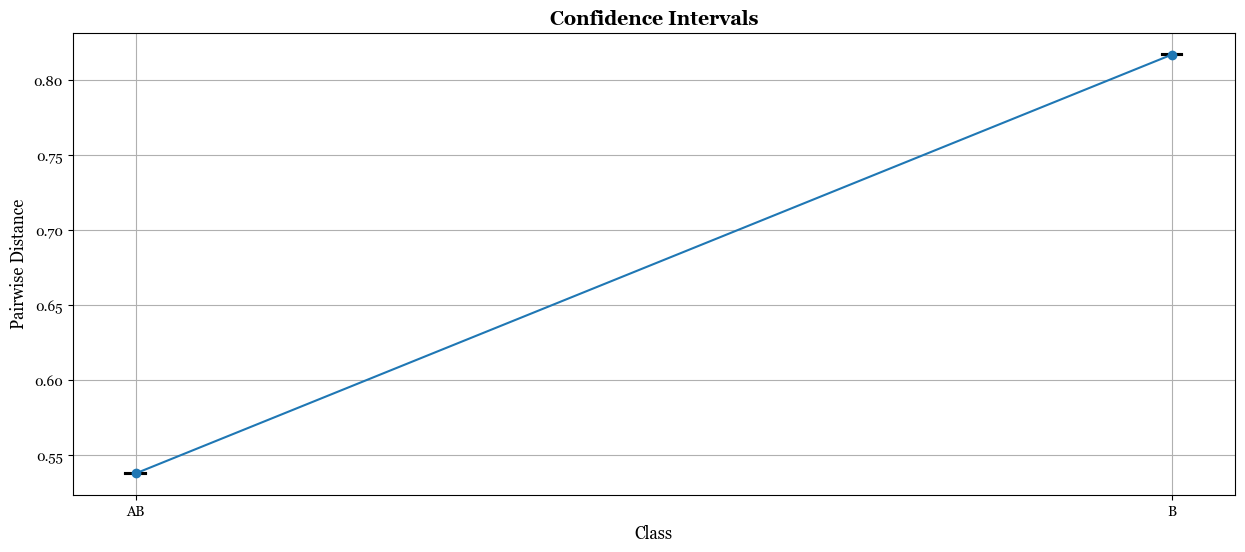

In [87]:
plot_intervals(pair_class_j_d, ['AB', 'B'], ['Class', 'Pairwise Distance'], 'ex3_CLS_J_DV_PD.pdf')

In [88]:
pair_class_v_d = pair_class_v.groupby('class')['value'].apply(
    lambda group: pd.Series(ci_mean(group.tolist()), index=['low', 'mean', 'high'])
    ).unstack().reset_index()
pair_class_v_d

,class,low,mean,high
0,AB,0.694654,0.694800,0.694947
1,B,0.714311,0.714964,0.715617


In [89]:
pg.pairwise_tests(data=pair_class_v, dv='value', between='class', padjust='holm')

,Contrast,A,B,Paired,Parametric,T,dof,alternative,p_unc,BF10,hedges
0,class,AB,B,False,True,-59.04335,166607.924805,two-sided,0.0,inf,-0.124208


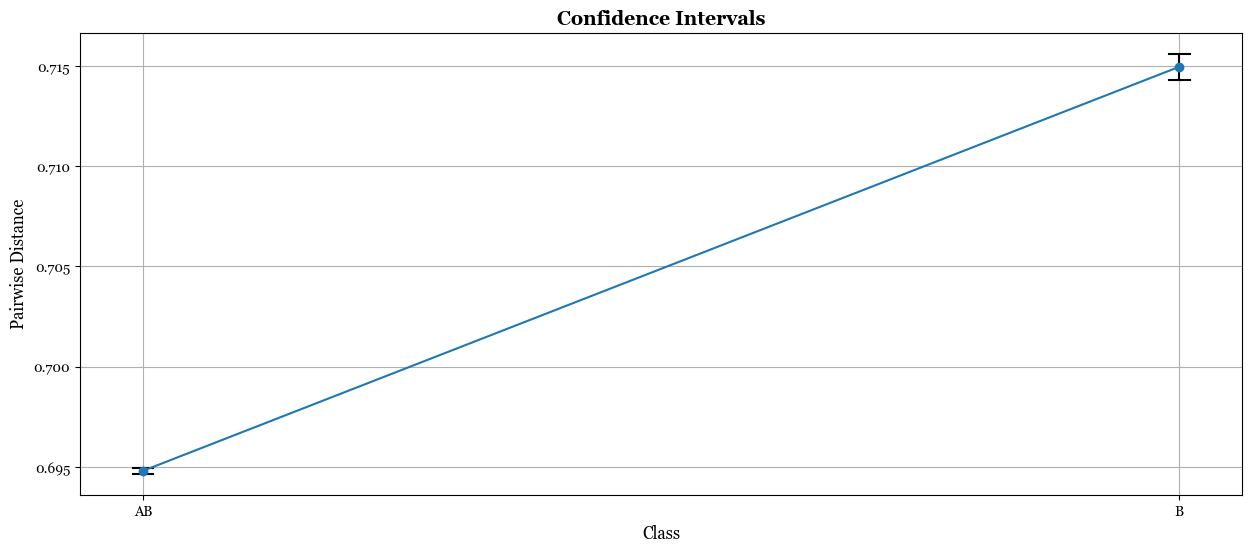

In [90]:
plot_intervals(pair_class_v_d, ['AB', 'B'], ['Class', 'Pairwise Distance'], 'ex3_CLS_V_DV_PD.pdf')

In [91]:
cent_class_j_d = cent_class_j.groupby('class')['value'].apply(
    lambda group: pd.Series(ci_mean(group.tolist()), index=['low', 'mean', 'high'])
    ).unstack().reset_index()
cent_class_j_d

,class,low,mean,high
0,AB,0.312485,0.320080,0.327675
1,B,0.560446,0.571018,0.581589


In [92]:
pg.pairwise_tests(data=cent_class_j, dv='value', between='class', padjust='holm')

,Contrast,A,B,Paired,Parametric,T,dof,alternative,p_unc,BF10,hedges
0,class,AB,B,False,True,-37.837416,1385.778198,two-sided,9.025622e-216,1.568e+245,-1.546426


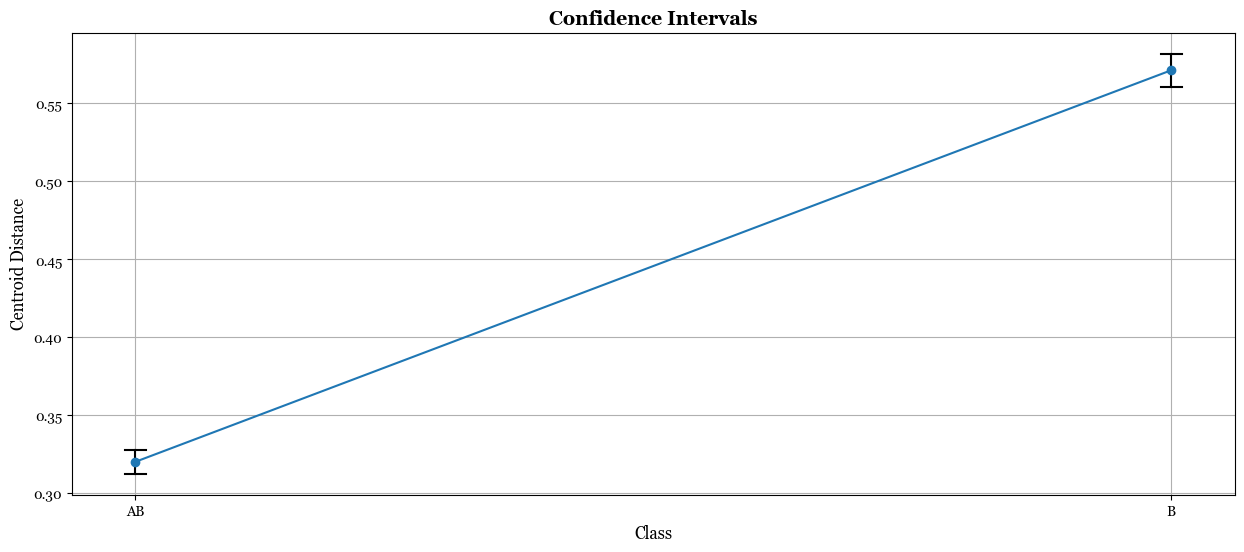

In [93]:
plot_intervals(cent_class_j_d, ['AB', 'B'], ['Class', 'Centroid Distance'], 'ex3_CLS_J_DV_CD.pdf')

In [94]:
cent_class_v_d = cent_class_v.groupby('class')['value'].apply(
    lambda group: pd.Series(ci_mean(group.tolist()), index=['low', 'mean', 'high'])
    ).unstack().reset_index()
cent_class_v_d

,class,low,mean,high
0,AB,0.441452,0.447590,0.453729
1,B,0.454346,0.465177,0.476008


In [95]:
pg.pairwise_tests(data=cent_class_v, dv='value', between='class', padjust='holm')

,Contrast,A,B,Paired,Parametric,T,dof,alternative,p_unc,BF10,hedges
0,class,AB,B,False,True,-2.773597,942.609355,two-sided,0.005653,2.352,-0.104745


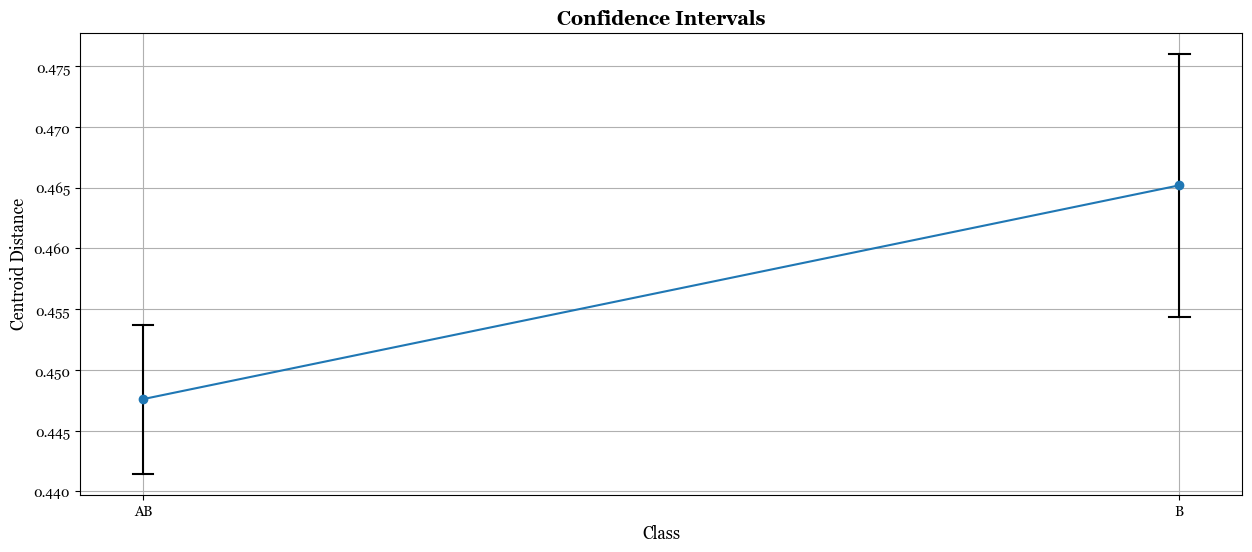

In [96]:
plot_intervals(cent_class_v_d, ['AB', 'B'], ['Class', 'Centroid Distance'], 'ex3_CLS_V_DV_CD.pdf')

In [97]:
result = vec_j.groupby('affix')['value'].apply(lambda g: cluster_dist(g.tolist()))

pair_affix_j = pd.DataFrame([
    {'affix': cls, 'value': x}
    for cls, (pairs, _) in result.items()
    for x in pairs
])

cent_affix_j = pd.DataFrame([
    {'affix': cls, 'value': x}
    for cls, (_, centers) in result.items()
    for x in centers
])

result = vec_v.groupby('affix')['value'].apply(lambda g: cluster_dist(g.tolist()))

pair_affix_v = pd.DataFrame([
    {'affix': cls, 'value': x}
    for cls, (pairs, _) in result.items()
    for x in pairs
])

cent_affix_v = pd.DataFrame([
    {'affix': cls, 'value': x}
    for cls, (_, centers) in result.items()
    for x in centers
])

In [98]:
pair_affix_j_d = pair_affix_j.groupby('affix')['value'].apply(
    lambda group: pd.Series(ci_mean(group.tolist()), index=['low', 'mean', 'high'])
    ).unstack().reset_index()
pair_affix_j_d

,affix,low,mean,high
0,',0.870211,0.885537,0.900863
1,ak,0.831165,0.844501,0.857838
2,ec,0.712897,0.717826,0.722756
3,ica,0.762965,0.773022,0.783079
4,ina,0.846151,0.857275,0.868398
5,izm,0.298450,0.307032,0.315614
6,ka,0.779274,0.781373,0.783473
7,nik,0.682478,0.684402,0.686326
8,ost',0.498605,0.498849,0.499092
9,ota,0.759864,0.770654,0.781444


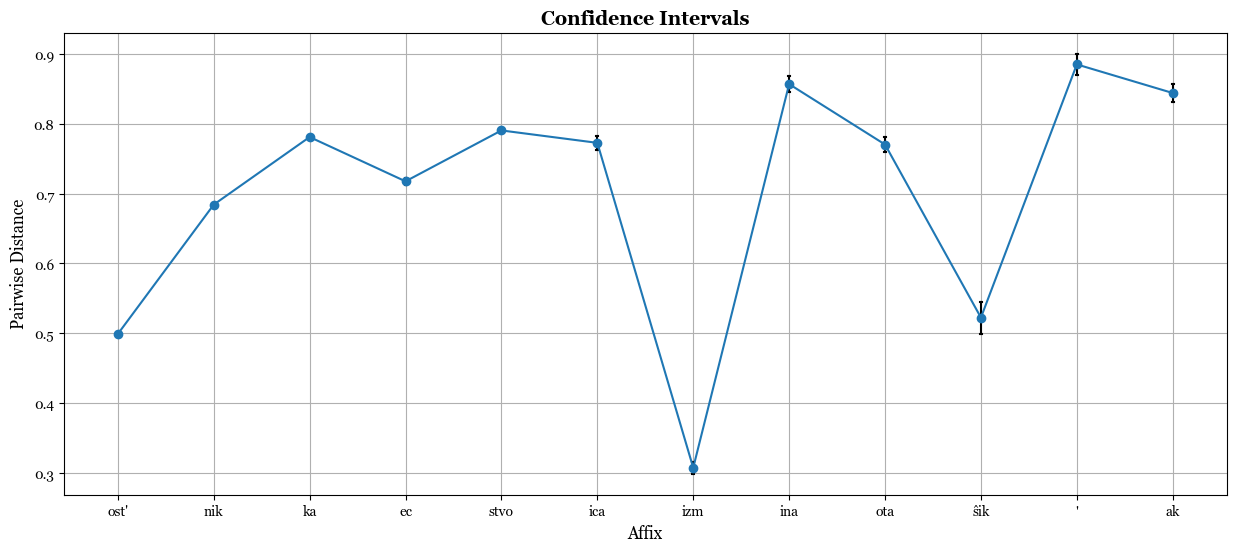

In [99]:
plot_intervals(pair_affix_j_d, adjectivalsorted, ['Affix', 'Pairwise Distance'], 'ex3_AFX_J_DV_PD.pdf')

In [100]:
cent_affix_j_d = cent_affix_j.groupby('affix')['value'].apply(
    lambda group: pd.Series(ci_mean(group.tolist()), index=['low', 'mean', 'high'])
    ).unstack().reset_index()
cent_affix_j_d

,affix,low,mean,high
0,',0.557300,0.610083,0.662866
1,ak,0.529336,0.561646,0.593956
2,ec,0.429680,0.463088,0.496496
3,ica,0.456600,0.506643,0.556687
4,ina,0.552308,0.595032,0.637755
5,izm,0.138868,0.163026,0.187185
6,ka,0.509552,0.528056,0.546561
7,nik,0.416742,0.435735,0.454727
8,ost',0.285593,0.292099,0.298605
9,ota,0.461946,0.498105,0.534265


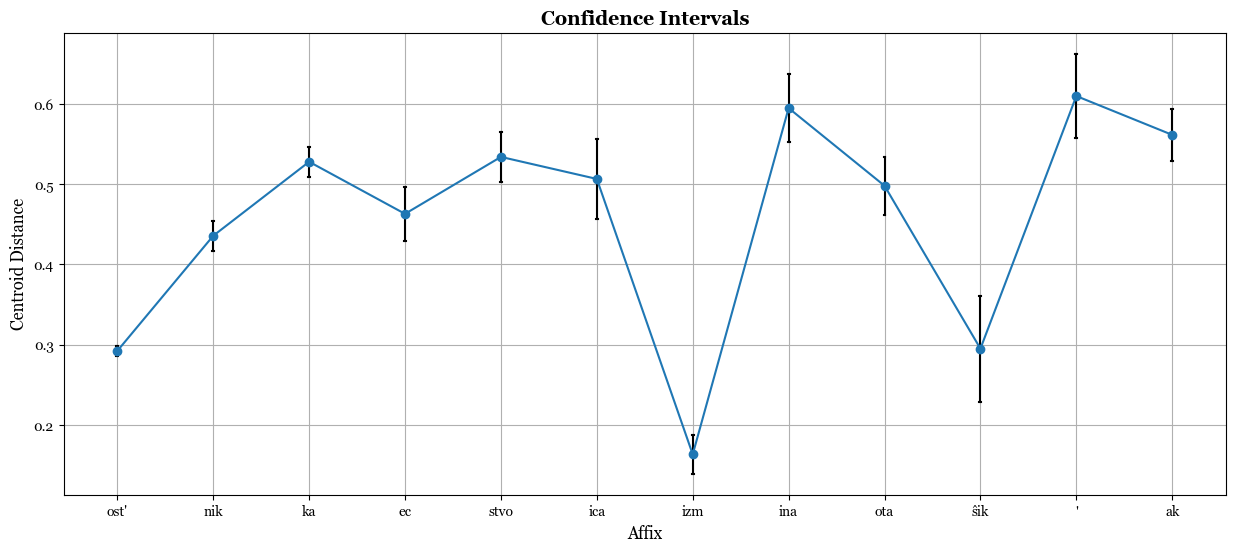

In [101]:
plot_intervals(cent_affix_j_d, adjectivalsorted, ['Affix', 'Centroid Distance'], 'ex3_AFX_J_DV_CD.pdf')

In [102]:
pair_affix_v_d = pair_affix_v.groupby('affix')['value'].apply(
    lambda group: pd.Series(ci_mean(group.tolist()), index=['low', 'mean', 'high'])
    ).unstack().reset_index()
pair_affix_v_d

,affix,low,mean,high
0,',0.783636,0.796529,0.809423
1,aciâ,0.531339,0.533290,0.535241
2,ator,0.515372,0.521020,0.526668
3,ec,0.784284,0.790776,0.797268
4,iŝe,0.743351,0.756546,0.769741
5,ka,0.738445,0.739015,0.739586
6,l,0.802313,0.811999,0.821684
7,l'ŝik,0.449331,0.462793,0.476256
8,nie,0.604163,0.604385,0.604607
9,nik,0.767392,0.772806,0.778221


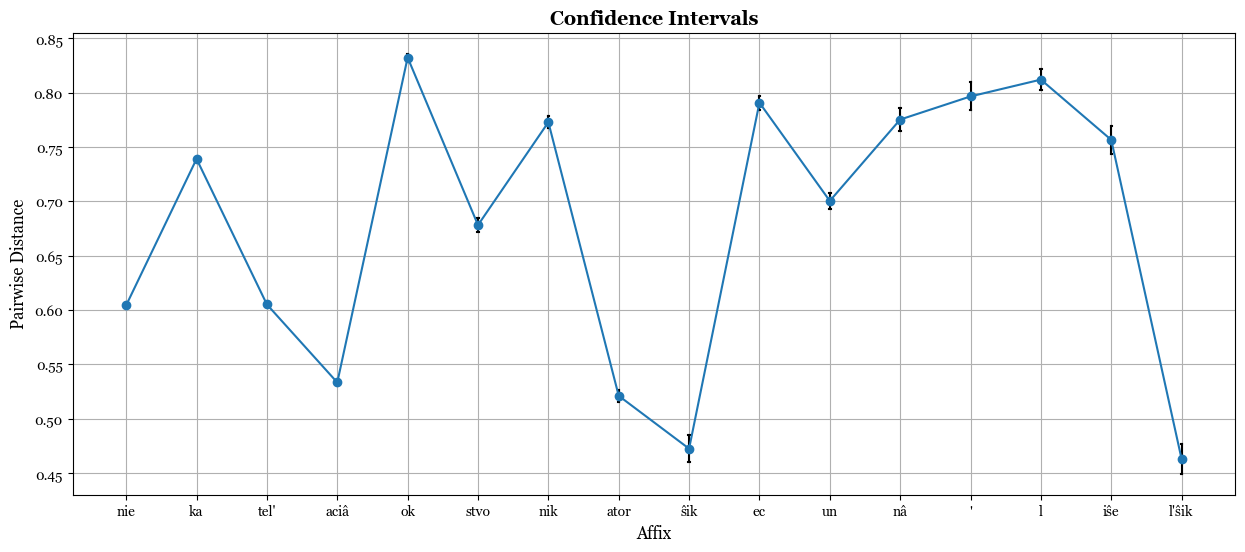

In [103]:
plot_intervals(pair_affix_v_d, verbalsorted, ['Affix', 'Pairwise Distance'], 'ex3_AFX_V_DV_PD.pdf')

In [104]:
cent_affix_v_d = cent_affix_v.groupby('affix')['value'].apply(
    lambda group: pd.Series(ci_mean(group.tolist()), index=['low', 'mean', 'high'])
    ).unstack().reset_index()
cent_affix_v_d

,affix,low,mean,high
0,',0.492258,0.524029,0.555800
1,aciâ,0.299719,0.315194,0.330668
2,ator,0.286516,0.301231,0.315947
3,ec,0.501755,0.522739,0.543722
4,iŝe,0.443493,0.478176,0.512858
5,ka,0.478264,0.488328,0.498391
6,l,0.504135,0.539567,0.574999
7,l'ŝik,0.221166,0.254033,0.286900
8,nie,0.364238,0.371019,0.377801
9,nik,0.485557,0.509744,0.533930


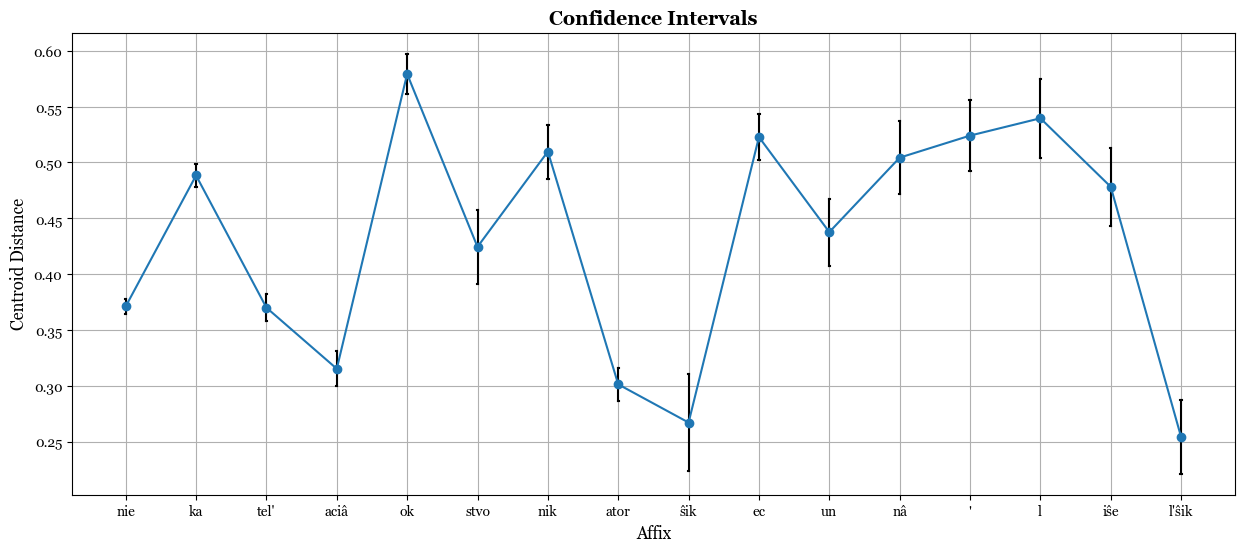

In [105]:
plot_intervals(cent_affix_v_d, verbalsorted, ['Affix', 'Centroid Distance'], 'ex3_AFX_V_DV_CD.pdf')

### Spearman

In [106]:
def crossexp(experiments, labels, file, verb=True):
    for i, df in enumerate(experiments):
        if verb:
            df['rank'] = df['affix'].apply(lambda x: verbalsorted.index(x) + 1)
        else:
            df['rank'] = df['affix'].apply(lambda x: adjectivalsorted.index(x) + 1)
        experiments[i] = df.sort_values('rank').reset_index(drop=True)
        corr, p_value = spearmanr(df['rank'], df['mean'])
        print(labels[i], corr, p_value)
    
    n_vars = len(experiments)
    corr_matrix = np.zeros((n_vars, n_vars))
    p_matrix = np.zeros((n_vars, n_vars))
    
    for i in range(n_vars):
        for j in range(n_vars):
            corr, p_value = spearmanr(experiments[i]['mean'], experiments[j]['mean'])
            corr_matrix[i, j] = corr
            p_matrix[i, j] = p_value
    

    plt.figure(figsize=(10, 8))
    sns.heatmap(p_matrix, annot=True, fmt='.2f', cmap='coolwarm',
                xticklabels=labels, yticklabels=labels)
    plt.title('p-value Matrix')
    plt.show()
    plt.figure(figsize=(10, 8))
    sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1, center=0,
                xticklabels=labels, yticklabels=labels)
    plt.title('Correlation Matrix')
    plt.savefig(file, bbox_inches='tight')

In [107]:
exp_v = [delta_affix_v, base_affix_v, pair_affix_v_w, cent_affix_v_w, pair_affix_v_d, cent_affix_v_d]
exp_j = [delta_affix_j, base_affix_j, pair_affix_j_w, cent_affix_j_w, pair_affix_j_d, cent_affix_j_d]
lab = ['∆', 'BD', 'PD (nouns)', 'CD (nouns)', 'PD (difference)', 'CD (difference)']

∆ -0.12352941176470587 0.6485420669723406
BD 0.6294117647058822 0.008988089264446915
PD (nouns) -0.1176470588235294 0.6643410791623537
CD (nouns) -0.17058823529411765 0.5276097688612683
PD (difference) 0.18235294117647058 0.4990748572458002
CD (difference) 0.12352941176470587 0.6485420669723406


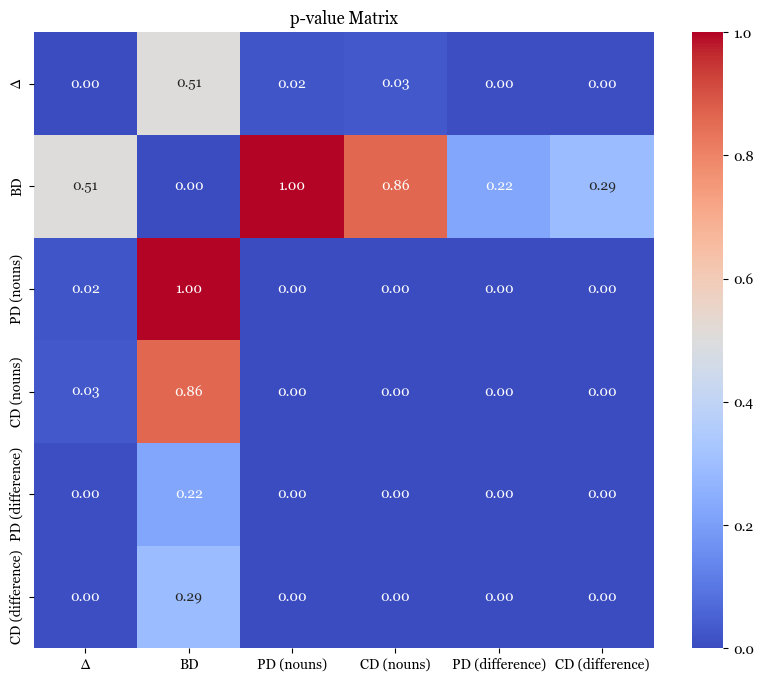

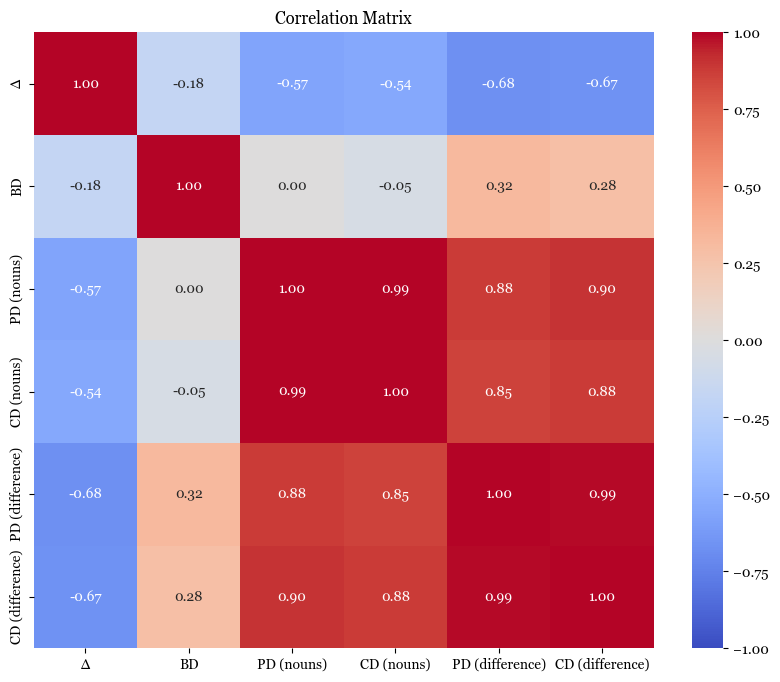

In [108]:
crossexp(exp_v, lab, 'spearman_V.pdf')

∆ 0.027972027972027972 0.9312343512018807
BD 0.8041958041958043 0.0016147689860699312
PD (nouns) 0.11188811188811189 0.729194990751066
CD (nouns) 0.0 1.0
PD (difference) 0.4545454545454546 0.13765791634772948
CD (difference) 0.4545454545454546 0.13765791634772948


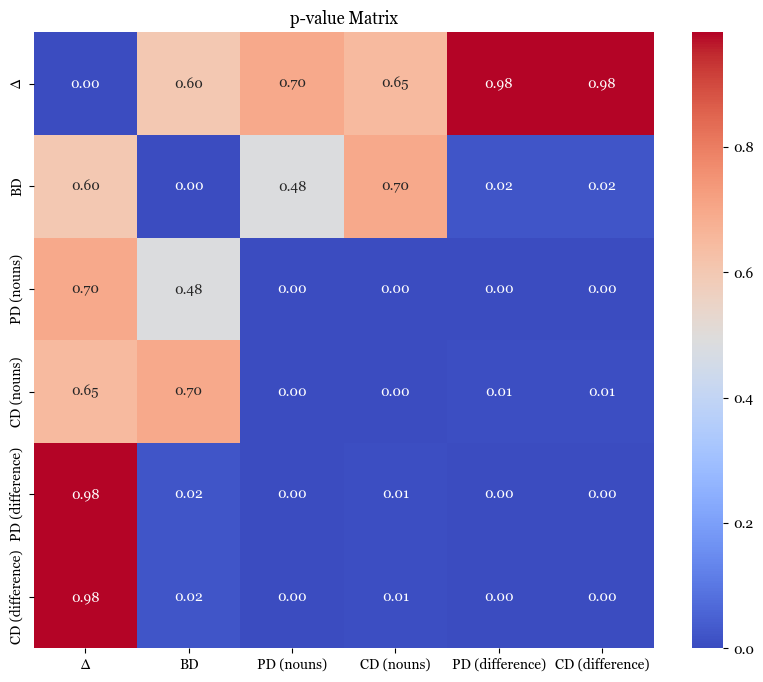

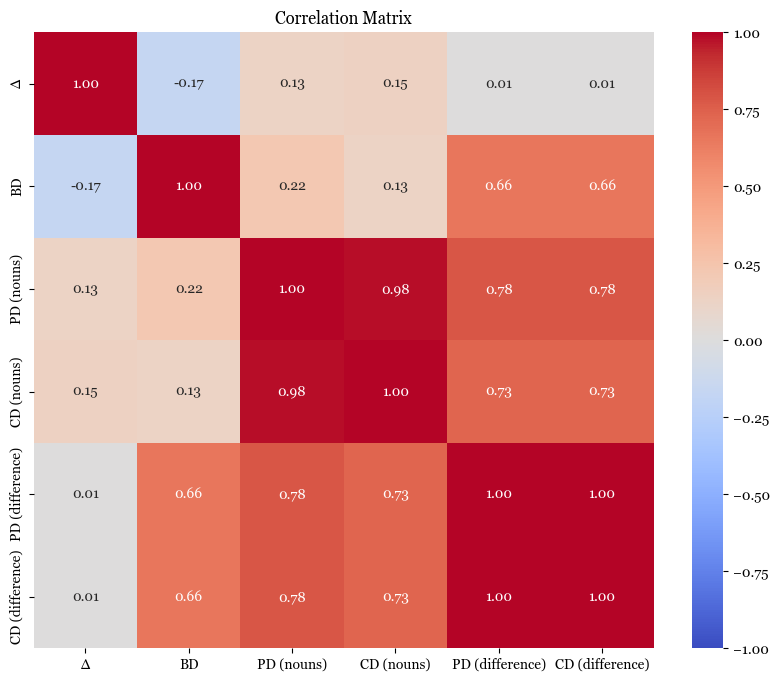

In [109]:
crossexp(exp_j, lab, 'spearman_J.pdf', False)

### Experiment 4

In [110]:
def reduce(X, y, labels, file):
    reducer = umap.UMAP(n_components=2, random_state=42, metric='cosine')
    X_2d = reducer.fit_transform(X)
    plt.figure(figsize=(7, 5))
    palette = sns.color_palette("tab10", n_colors=len(set(y)))
    for i, label in enumerate(labels):
        mask = np.array(y) == label
        plt.scatter(X_2d[mask, 0], X_2d[mask, 1], color=palette[i], alpha=0.1, label=label)
    legend = plt.legend()
    for handle in legend.legend_handles:
        handle.set_alpha(1)
    plt.savefig(file, bbox_inches='tight')

In [111]:
def classify(X, y, labels, file, figsize=(14, 10), normalize=False):
    le = LabelEncoder()
    y_encoded = le.fit_transform(y)

    cv = KFold(n_splits=10, shuffle=True, random_state=42)
    classifier = xgb.XGBClassifier(n_estimators=100, random_state=42)

    y_pred = cross_val_predict(classifier, X, y_encoded, cv=cv)
    print(classification_report(y_encoded, y_pred))
    accuracy = accuracy_score(y_encoded, y_pred)

    cm = confusion_matrix(y_encoded, y_pred, labels=[list(le.classes_).index(a) for a in labels])
    if normalize:
        cm = cm / cm.sum(axis=1, keepdims=True)
        fmt = '.2f'
    else:
        fmt = 'd'
    plt.figure(figsize=figsize)
    sns.heatmap(cm, annot=True, fmt=fmt, cmap='Blues', xticklabels=labels, 
                yticklabels=labels)
    plt.xlabel('Predicted Label')
    plt.ylabel('Actual Label')
    plt.title(f'Confusion Matrix (Accuracy: {accuracy:.2f})')
    plt.savefig(file, bbox_inches='tight')

    misclassified_indices = np.where(y_encoded != y_pred)[0]
    misclassified_details = {
        'indices': misclassified_indices.tolist(),
        'true_labels': le.inverse_transform(y_encoded[misclassified_indices]).tolist(),
        'predicted_labels': le.inverse_transform(y_pred[misclassified_indices]).tolist()
    }
    return misclassified_details

d:\coding\thesis\venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


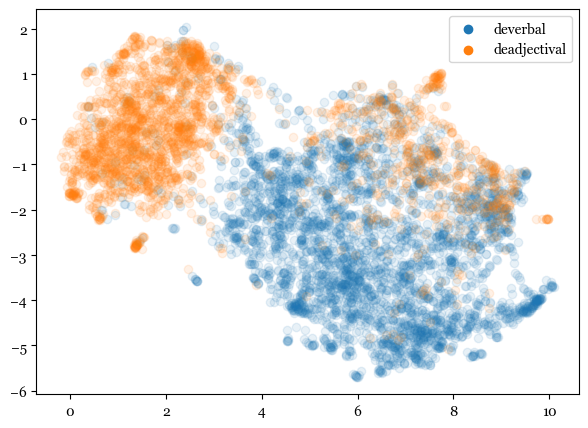

In [112]:
reduce(v2n['der_vec'].tolist() + j2n['der_vec'].tolist(), ['deverbal'] * len(v2n) + ['deadjectival'] * len(j2n), ['deverbal', 'deadjectival'], 'ex4_VJ_UMAP_vec.pdf')

              precision    recall  f1-score   support

           0       0.93      0.89      0.91      2578
           1       0.92      0.96      0.94      3633

    accuracy                           0.93      6211
   macro avg       0.93      0.92      0.92      6211
weighted avg       0.93      0.93      0.93      6211



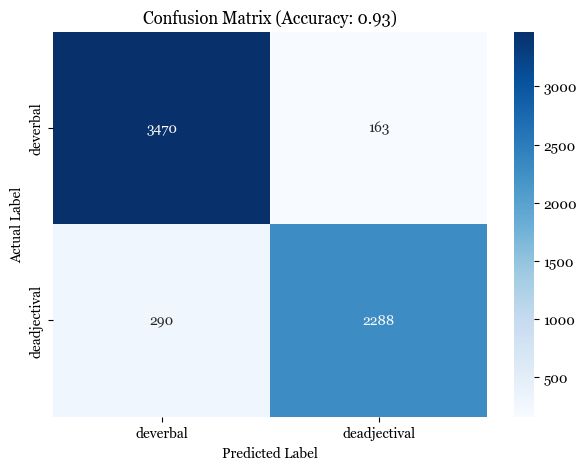

In [113]:
derived_mis = classify(v2n['der_vec'].tolist() + j2n['der_vec'].tolist(), ['deverbal'] * len(v2n) + ['deadjectival'] * len(j2n), ['deverbal', 'deadjectival'], 'ex4_VJ_XG_vec.pdf', (7, 5))

d:\coding\thesis\venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


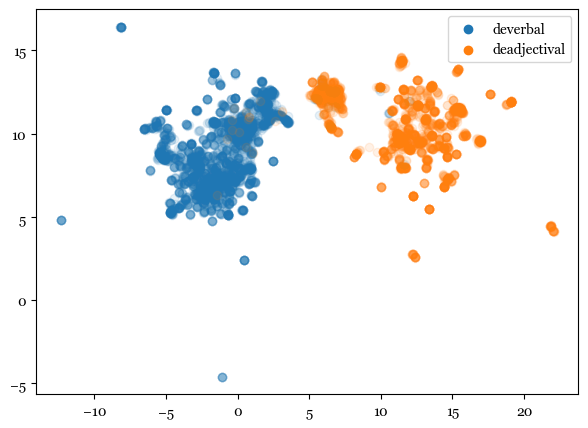

In [114]:
reduce(dif_v + dif_j, ['deverbal'] * len(v2n) + ['deadjectival'] * len(j2n), ['deverbal', 'deadjectival'], 'ex4_VJ_UMAP_dif.pdf')

              precision    recall  f1-score   support

           0       1.00      0.99      0.99      2578
           1       0.99      1.00      1.00      3633

    accuracy                           1.00      6211
   macro avg       1.00      0.99      0.99      6211
weighted avg       1.00      1.00      1.00      6211



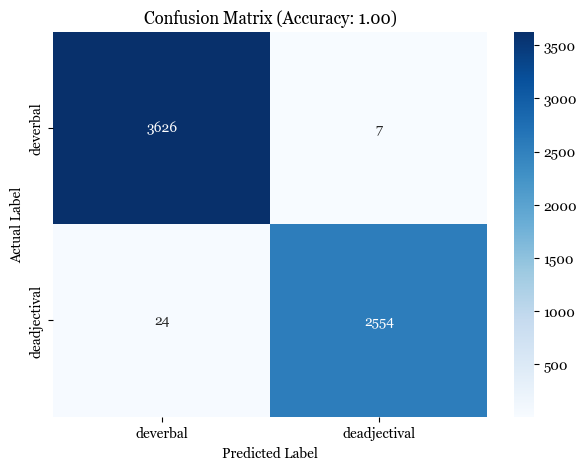

In [115]:
difrences_mis = classify(dif_v + dif_j, ['deverbal'] * len(v2n) + ['deadjectival'] * len(j2n), ['deverbal', 'deadjectival'], 'ex4_VJ_XG_dif.pdf', (7, 5))

In [116]:
derivates = [(x, 'v') for x in v2n['der'].tolist()] + [(x, 'j') for x in j2n['der'].tolist()]
missclassified_der = [derivates[i] for i in derived_mis['indices']]
missclassified_dif = [derivates[i] for i in difrences_mis['indices']]
set(missclassified_dif) & set(missclassified_der)

{('белка', 'j'),
 ('десятник', 'j'),
 ('должник', 'j'),
 ('единица', 'j'),
 ('клейковина', 'j'),
 ('множество', 'j'),
 ('молодняк', 'j'),
 ('одурь', 'v'),
 ('сырь', 'j')}

In [117]:
yj_class, yj_affix = [], []
for index, row in j2n.iterrows():
    a = adj2clean[row['affix']]
    c = adjclass[a]
    yj_class.append(c + ' (deadjectival)')
    yj_affix.append(a)

yv_class, yv_affix = [], []
for index, row in v2n.iterrows():
    a = verb2clean[row['affix']]
    c = verbclass[a]
    yv_class.append(c + ' (deverbal)')
    yv_affix.append(a)

d:\coding\thesis\venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


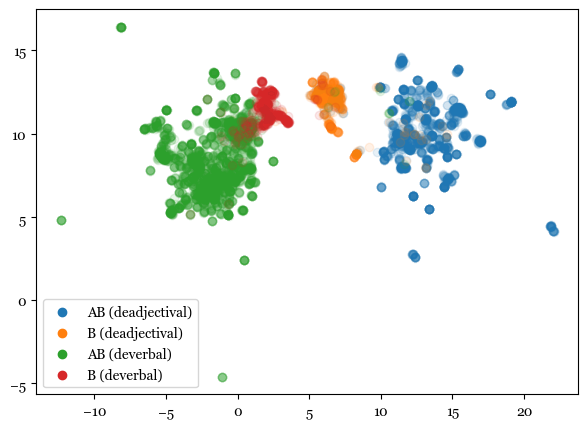

In [118]:
reduce(dif_v + dif_j, yv_class + yj_class, ['AB (deadjectival)', 'B (deadjectival)', 'AB (deverbal)', 'B (deverbal)'], 'ex4_CLS_UMAP.pdf')

              precision    recall  f1-score   support

           0       0.99      0.98      0.98      1920
           1       0.95      0.96      0.96       658

    accuracy                           0.98      2578
   macro avg       0.97      0.97      0.97      2578
weighted avg       0.98      0.98      0.98      2578



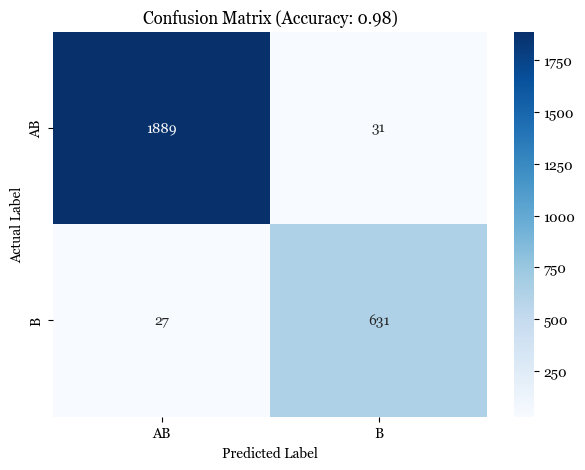

In [119]:
clsj_mis = classify(dif_j, [y.split()[0] for y in yj_class], ['AB', 'B'], 'ex4_CLS_XG_J.pdf', (7, 5))

              precision    recall  f1-score   support

           0       0.98      1.00      0.99      3083
           1       0.97      0.90      0.94       550

    accuracy                           0.98      3633
   macro avg       0.98      0.95      0.96      3633
weighted avg       0.98      0.98      0.98      3633



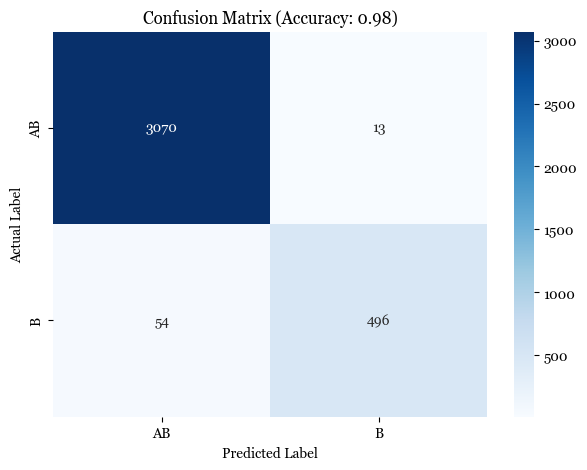

In [120]:
clsv_mis = classify(dif_v, [y.split()[0] for y in yv_class], ['AB', 'B'], 'ex4_CLS_XG_V.pdf', (7, 5))

In [121]:
derivates = [x for x in j2n['der'].tolist()]
for i, idx in enumerate(clsj_mis['indices']):
    if clsj_mis['true_labels'][i] == 'A' and clsj_mis['predicted_labels'][i] == 'B':
        print(derivates[idx])

              precision    recall  f1-score   support

           0       0.57      0.18      0.28        22
           1       0.56      0.23      0.32        22
           2       0.88      0.79      0.83       107
           3       0.64      0.42      0.51        43
           4       0.79      0.39      0.53        38
           5       0.97      0.92      0.95        38
           6       0.81      0.88      0.84       169
           7       0.84      0.94      0.88       216
           8       0.95      0.99      0.97      1772
           9       0.50      0.09      0.15        33
          10       0.79      0.58      0.67        93
          11       0.87      0.80      0.83        25

    accuracy                           0.91      2578
   macro avg       0.76      0.60      0.65      2578
weighted avg       0.90      0.91      0.90      2578



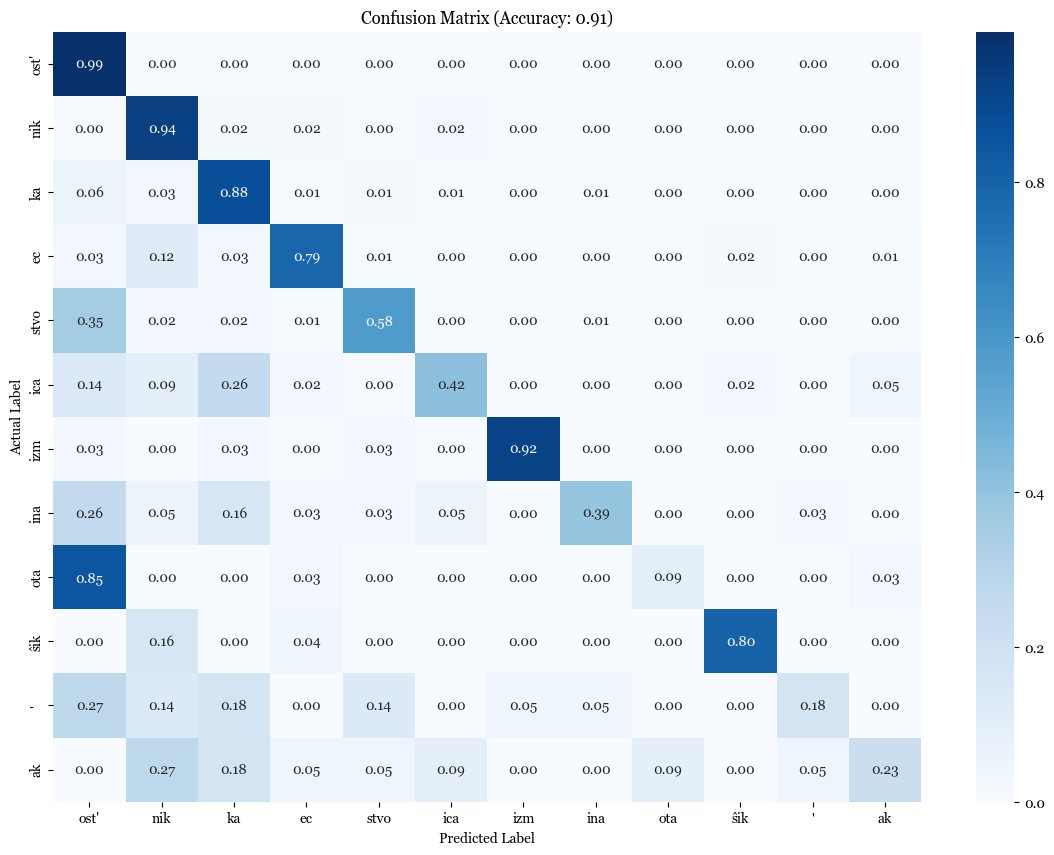

In [122]:
afxj_mis = classify(dif_j, yj_affix, adjectivalsorted, 'ex4_AFX_J.pdf', (14, 10), True)

              precision    recall  f1-score   support

           0       0.88      0.21      0.34        33
           1       0.96      0.85      0.90       217
           2       0.90      0.83      0.87        54
           3       0.53      0.39      0.45        41
           4       0.87      0.52      0.65        25
           5       0.80      0.95      0.87       633
           6       0.64      0.22      0.33        32
           7       0.90      0.83      0.86        23
           8       0.95      0.99      0.97      1990
           9       0.76      0.39      0.52        56
          10       0.70      0.20      0.31        35
          11       0.64      0.29      0.40        85
          12       0.89      0.60      0.72        65
          13       0.89      0.94      0.92       258
          14       0.84      0.66      0.74        41
          15       0.90      0.78      0.83        45

    accuracy                           0.90      3633
   macro avg       0.82   

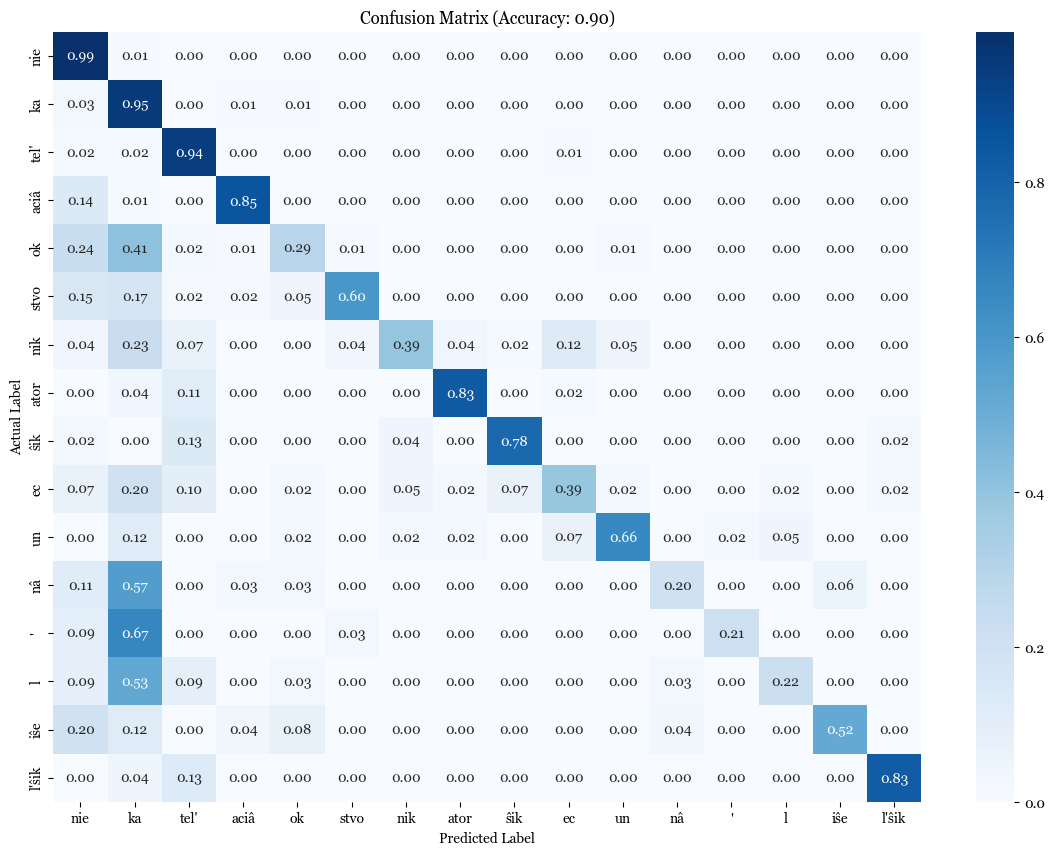

In [123]:
afxv_mis = classify(dif_v, yv_affix, verbalsorted, 'ex4_AFX_V.pdf', (14, 10), True)

In [124]:
def crossclassify(X_train, y_train, X_test, y_test, labels_train, labels_test, file, figsize=(14, 10), normalize=True):

    all_labels = list(dict.fromkeys(labels_train + labels_test))
    label_to_int = {lbl: i for i, lbl in enumerate(all_labels)}
    y_train_encoded = np.array([label_to_int[y] for y in y_train])
    y_test_encoded = np.array([label_to_int[y] for y in y_test])

    classifier = xgb.XGBClassifier(n_estimators=100,random_state=42)
    classifier.fit(X_train, y_train_encoded)
    y_pred_encoded = classifier.predict(X_test)

    full_order = list(range(len(all_labels)))

    cm = confusion_matrix(y_test_encoded, y_pred_encoded, labels=full_order)

    row_order = [label_to_int[lbl] for lbl in labels_test]
    col_order = [label_to_int[lbl] for lbl in labels_train]
    cm = cm[np.ix_(row_order, col_order)]

    if normalize:
        row_sums = cm.sum(axis=1, keepdims=True)
        row_sums[row_sums == 0] = 1
        cm = cm.astype(float) / row_sums
        fmt = '.2f'
    else:
        fmt = 'd'

    plt.figure(figsize=figsize)
    sns.heatmap(cm, annot=True, fmt=fmt, cmap='Blues',
        xticklabels=labels_train,
        yticklabels=labels_test
    )

    plt.xlabel('Predicted Label')
    plt.ylabel('Actual Label')
    plt.title('Confusion Matrix')

    plt.savefig(file, bbox_inches='tight')

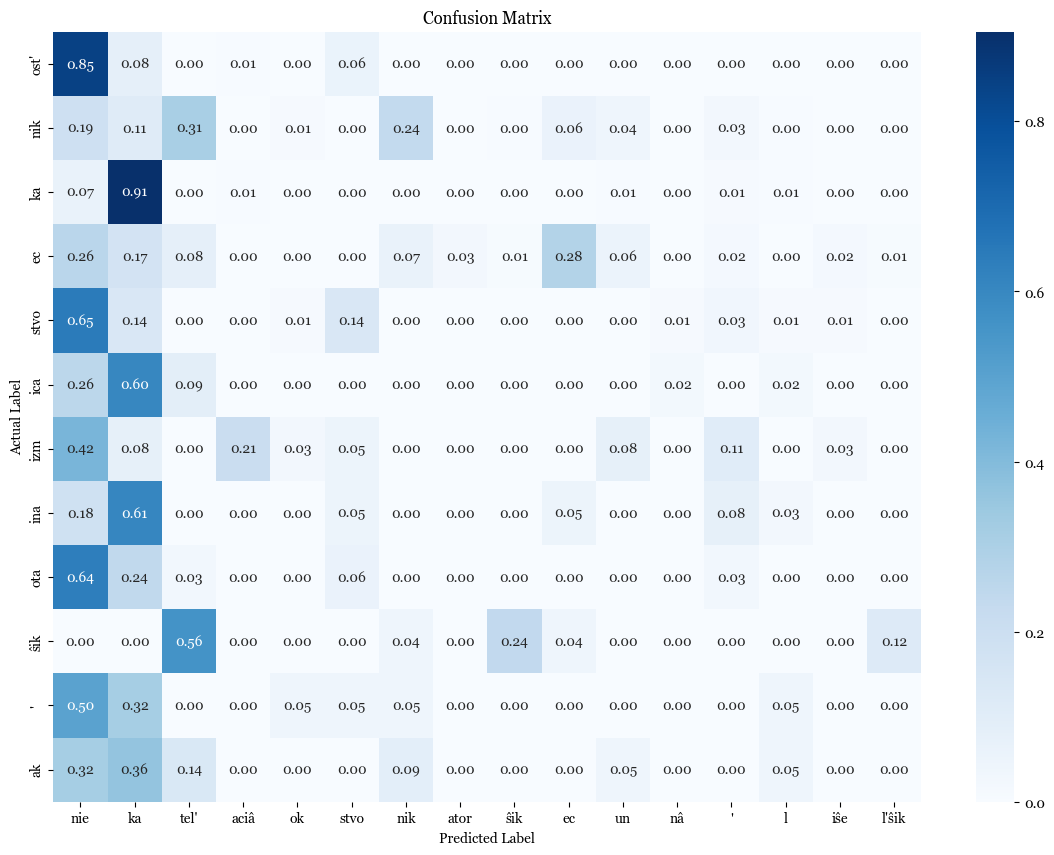

In [125]:
crossclassify(dif_v, yv_affix, dif_j, yj_affix, verbalsorted, adjectivalsorted, 'ex4_AFX_JV.pdf')

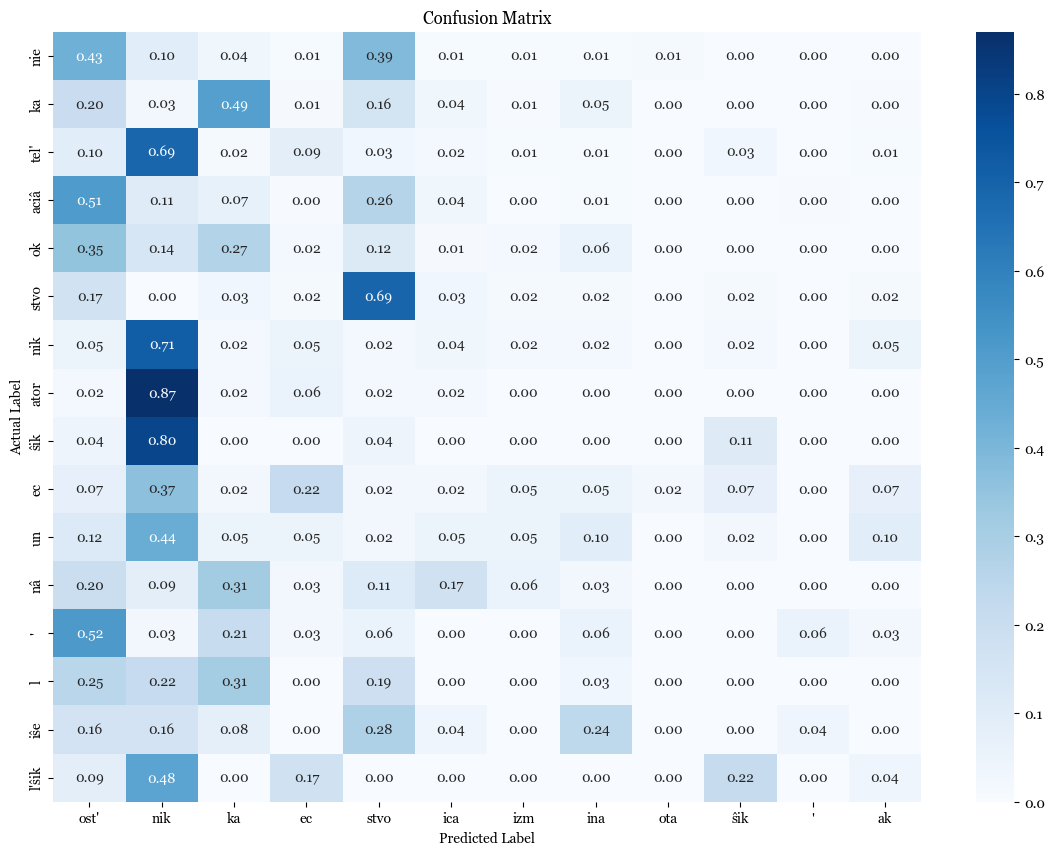

In [126]:
crossclassify(dif_j, yj_affix, dif_v, yv_affix, adjectivalsorted, verbalsorted, 'ex4_AFX_VJ.pdf')